# Compare Trained Go/No-Go Networks

This notebook loads the trained low-rank RNN, full-rank RNN, and LSTM from `homework_CN/outputs`, tests them on the same 3-context Go/No-Go task, and compares:

- training curves and final performance
- final scalar outputs for every context/stimulus rule
- output trajectories across the 10 timestep trial
- hidden-state PCA trajectories as a first look at latent dynamics

Test design: 3 repeated trials for each of the 6 task cases: `3 contexts x 2 stimuli x 3 repeats = 18 trials`.

## 1. Setup

The notebook is written to run either from the project root or from inside `homework_CN`.

In [8]:
from pathlib import Path
import sys
import json
from types import SimpleNamespace

import numpy as np
import pandas as pd
import torch as T
import torch.nn.functional as F
import matplotlib.pyplot as plt

# Resolve paths robustly for either project-root or homework_CN working directories.
CWD = Path.cwd()
if (CWD / "train_context_gonogo.py").exists() and (CWD / "outputs").exists():
    HOMEWORK_DIR = CWD
else:
    HOMEWORK_DIR = CWD / "homework_CN"

OUTPUT_DIR = HOMEWORK_DIR / "outputs"
sys.path.insert(0, str(HOMEWORK_DIR))

from low_rank_rnn import LowRankRNN
from full_rank_rnn import FullRankRNN
from lstm_rnn import LSTMRNN
from train_context_gonogo import ContextGoNoGoTask

DEVICE = T.device("cuda" if T.cuda.is_available() else "cpu")
print("HOMEWORK_DIR:", HOMEWORK_DIR)
print("OUTPUT_DIR:", OUTPUT_DIR)
print("DEVICE:", DEVICE)

HOMEWORK_DIR: /Users/utsai/Documents/tsai_project/homework_CN
OUTPUT_DIR: /Users/utsai/Documents/tsai_project/homework_CN/outputs
DEVICE: cpu


## 2. Load Trained Networks

The loader reads the checkpoint metadata and reconstructs each architecture with the same `hidden_size`, `rank`, `seq_len`, and `alpha` used during training.

In [9]:
MODEL_FILES = {
    "low_rank": OUTPUT_DIR / "low_rank_final_model.pt",
    "full_rank": OUTPUT_DIR / "full_rank_final_model.pt",
    "lstm": OUTPUT_DIR / "lstm_final_model.pt",
}


def build_model(model_type, args):
    common = dict(input_size=5, hidden_size=args.hidden_size, output_size=1)
    if model_type == "low_rank":
        return LowRankRNN(rank=args.rank, alpha=args.alpha, **common)
    if model_type == "full_rank":
        return FullRankRNN(alpha=args.alpha, **common)
    if model_type == "lstm":
        return LSTMRNN(**common)
    raise ValueError(f"Unknown model type: {model_type}")


def load_trained_model(path):
    ckpt = T.load(path, map_location=DEVICE)
    args = SimpleNamespace(**ckpt["args"])
    model_type = ckpt["model_type"]
    model = build_model(model_type, args).to(DEVICE)
    model.load_state_dict(ckpt["model_state_dict"])
    model.eval()
    return model, args, ckpt

models = {}
model_args = {}
checkpoints = {}
for name, path in MODEL_FILES.items():
    model, args, ckpt = load_trained_model(path)
    models[name] = model
    model_args[name] = args
    checkpoints[name] = ckpt
    n_trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"{name:9s} | hidden={args.hidden_size} rank={args.rank} seq_len={args.seq_len} alpha={args.alpha} trainable={n_trainable:,}")

low_rank  | hidden=256 rank=1 seq_len=10 alpha=0.2 trainable=2,048
full_rank | hidden=256 rank=1 seq_len=10 alpha=0.2 trainable=67,072
lstm      | hidden=256 rank=1 seq_len=10 alpha=0.2 trainable=269,569


## 3. Compare Training Curves

These curves come from the saved `*_metrics.json` files created during training.

In [10]:
def load_metrics(name):
    with (OUTPUT_DIR / f"{name}_metrics.json").open() as f:
        return json.load(f)

metrics = {name: load_metrics(name) for name in models}
summary_rows = []
for name, data in metrics.items():
    args = model_args[name]
    summary_rows.append({
        "model": name,
        "steps": args.steps,
        "hidden_size": args.hidden_size,
        "rank": args.rank if name == "low_rank" else None,
        "repeats_per_case": args.repeats_per_case,
        "final_accuracy": data["final_accuracy"],
        "final_mse": data["final_mse"],
    })
summary_df = pd.DataFrame(summary_rows)
summary_df

,model,steps,hidden_size,rank,repeats_per_case,final_accuracy,final_mse
0,low_rank,10000,256,1.0,4,1.0,6.347515e-13
1,full_rank,5000,256,NaN,4,1.0,4.249175e-07
2,lstm,5000,256,NaN,4,1.0,6.766134e-10


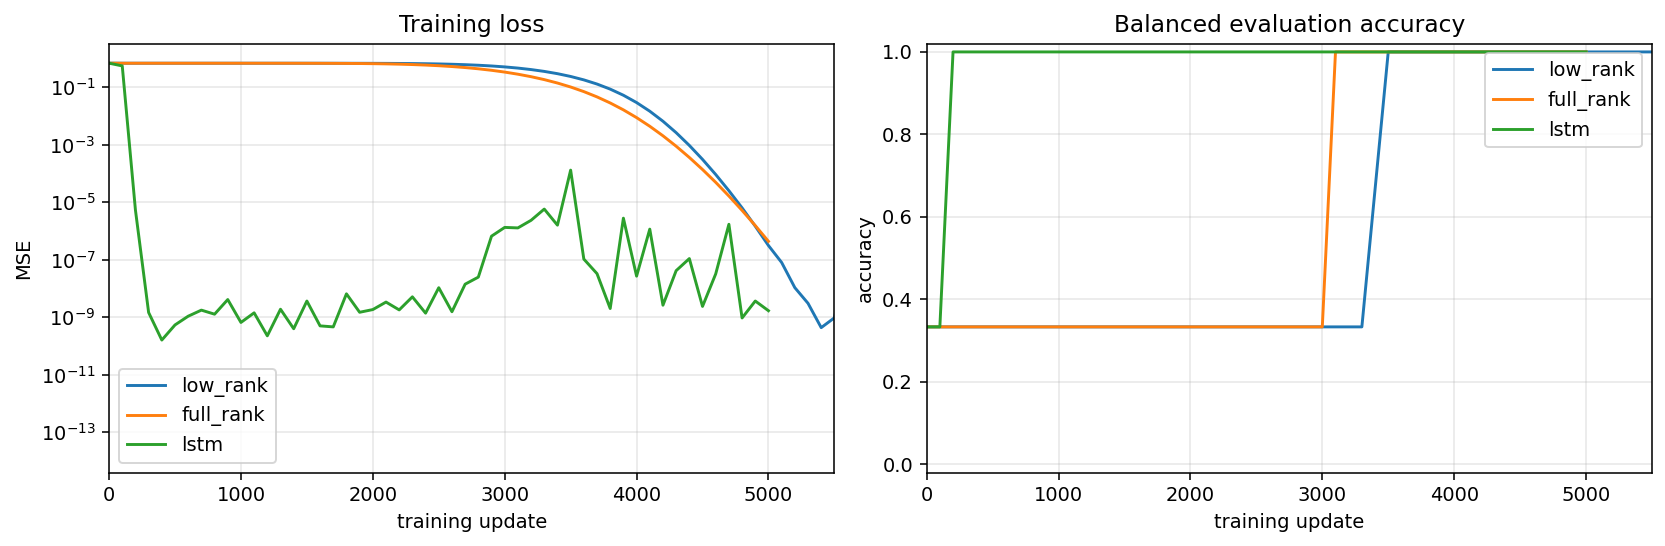

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), dpi=140)

for name, data in metrics.items():
    hist = data["history"]
    axes[0].plot(hist["step"], hist["loss"], label=name)
    axes[1].plot(hist["step"], hist["accuracy"], label=name)

axes[0].set_title("Training loss")
axes[0].set_xlabel("training update")
axes[0].set_ylabel("MSE")
axes[0].set_xlim(0, 5500)
axes[0].set_yscale("log")
axes[0].grid(True, alpha=0.3)
axes[0].legend()

axes[1].set_title("Balanced evaluation accuracy")
axes[1].set_xlabel("training update")
axes[1].set_ylabel("accuracy")
axes[1].set_ylim(-0.02, 1.02)
axes[1].set_xlim(0, 5500)
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

## 4. Build a Small Test Set

We test 3 repeated trials per context/stimulus pair. Because the task and networks are deterministic, repeated trials should produce identical outputs; keeping repeats makes the test design explicit and easy to explain.

In [12]:
task = ContextGoNoGoTask(seq_len=model_args["low_rank"].seq_len)
TEST_REPEATS_PER_CASE = 3
inputs, targets, contexts, stimuli = task.make_balanced_batch(TEST_REPEATS_PER_CASE, DEVICE)

case_df = pd.DataFrame({
    "trial": np.arange(len(contexts.cpu())),
    "context": contexts.cpu().numpy(),
    "stimulus": stimuli.cpu().numpy().astype(int),
    "target": targets.squeeze(1).cpu().numpy().astype(int),
})
case_df.head(18)

,trial,context,stimulus,target
0,0,0,-1,0
1,1,0,-1,0
2,2,0,-1,0
3,3,0,1,0
4,4,0,1,0
5,5,0,1,0
6,6,1,-1,-1
7,7,1,-1,-1
8,8,1,-1,-1
9,9,1,1,1


## 5. Output and Performance on the Test Set

The networks produce a scalar output. For behavioral accuracy, scalar outputs are discretized into `-1`, `0`, `+1` using thresholds at `-1/3` and `+1/3`.

In [13]:
@T.no_grad()
def run_test_set(model):
    outputs, states = model(inputs, return_states=True)
    final_output = outputs[:, -1, :]
    pred = task.discretize(final_output)
    acc = (task.value_to_index(pred) == task.value_to_index(targets)).float().mean().item()
    mse = F.mse_loss(final_output, targets).item()
    return outputs.cpu(), states.cpu(), final_output.cpu(), pred.cpu(), acc, mse

results = {}
for name, model in models.items():
    outputs, states, final_output, pred, acc, mse = run_test_set(model)
    results[name] = {
        "outputs": outputs,
        "states": states,
        "final_output": final_output,
        "prediction": pred,
        "accuracy": acc,
        "mse": mse,
    }
    print(f"{name:9s} | test accuracy={acc:.3f} | test MSE={mse:.3e}")

low_rank  | test accuracy=1.000 | test MSE=6.516e-13
full_rank | test accuracy=1.000 | test MSE=4.249e-07
lstm      | test accuracy=1.000 | test MSE=2.202e-09


In [14]:
rows = []
for name, res in results.items():
    for i in range(len(case_df)):
        rows.append({
            "model": name,
            "trial": i,
            "context": int(contexts[i].cpu()),
            "stimulus": int(stimuli[i].cpu()),
            "target": int(targets[i].item()),
            "raw_output": float(res["final_output"][i].item()),
            "prediction": int(res["prediction"][i].item()),
        })
output_df = pd.DataFrame(rows)
output_df.head(18)

,model,trial,context,stimulus,target,raw_output,prediction
0,low_rank,0,0,-1,0,1.579523e-06,0
1,low_rank,1,0,-1,0,1.579523e-06,0
2,low_rank,2,0,-1,0,1.579523e-06,0
3,low_rank,3,0,1,0,3.278255e-07,0
4,low_rank,4,0,1,0,3.278255e-07,0
5,low_rank,5,0,1,0,3.278255e-07,0
6,low_rank,6,1,-1,-1,-9.999995e-01,-1
7,low_rank,7,1,-1,-1,-9.999995e-01,-1
8,low_rank,8,1,-1,-1,-9.999995e-01,-1
9,low_rank,9,1,1,1,1.000000e+00,1


In [15]:
# Average repeated trials for a compact 6-case comparison.
case_mean = (
    output_df
    .groupby(["model", "context", "stimulus", "target"], as_index=False)
    .agg(raw_output=("raw_output", "mean"), prediction=("prediction", "first"))
)
case_mean

,model,context,stimulus,target,raw_output,prediction
0,full_rank,0,-1,0,-2.067387e-04,0
1,full_rank,0,1,0,2.537668e-04,0
2,full_rank,1,-1,-1,-9.990601e-01,-1
3,full_rank,1,1,1,9.990821e-01,1
4,full_rank,2,-1,1,9.994161e-01,1
5,full_rank,2,1,-1,-9.993871e-01,-1
6,low_rank,0,-1,0,1.579523e-06,0
7,low_rank,0,1,0,3.278255e-07,0
8,low_rank,1,-1,-1,-9.999995e-01,-1
9,low_rank,1,1,1,1.000000e+00,1


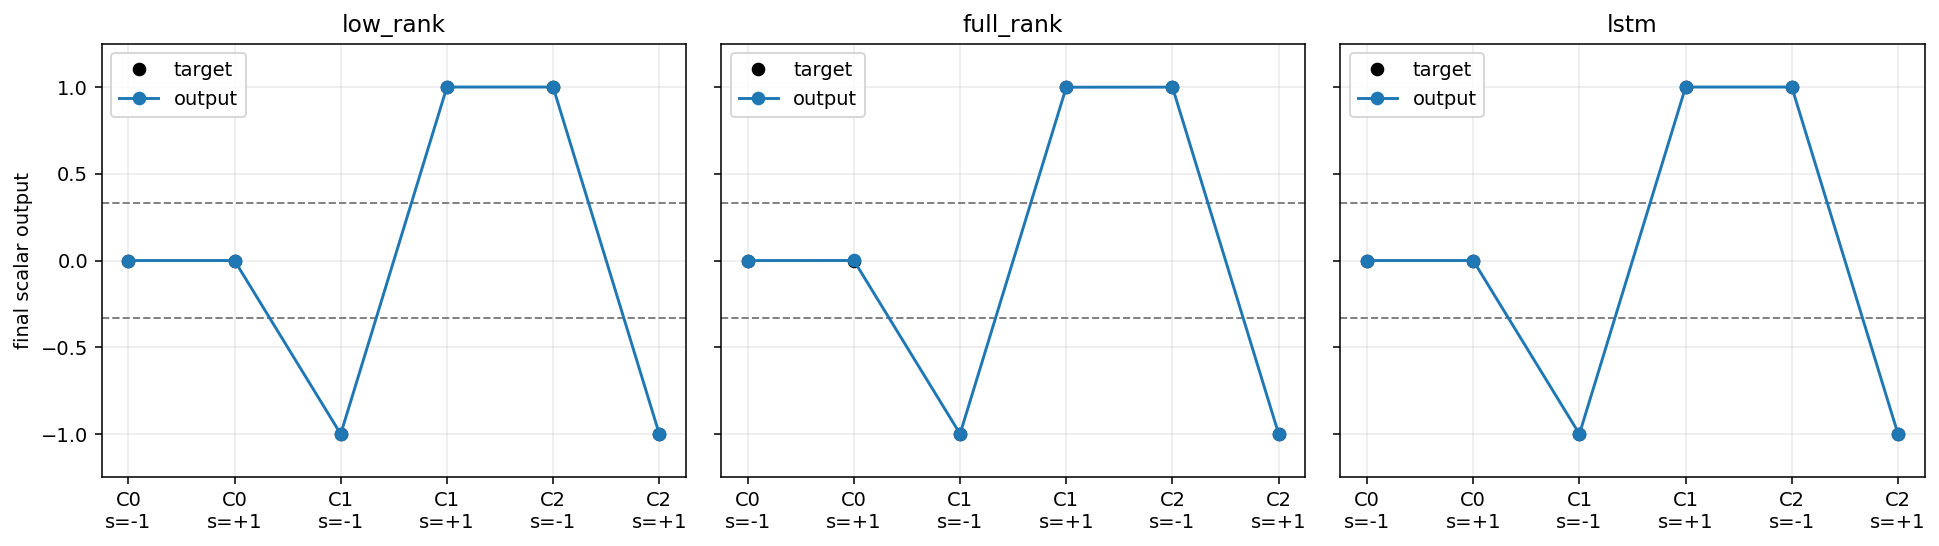

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True, dpi=140)
case_order = [(c, s) for c in range(3) for s in (-1, 1)]
x = np.arange(len(case_order))
labels = [f"C{c}\ns={s:+d}" for c, s in case_order]

target_values = []
for c, s in case_order:
    target_values.append(case_mean[(case_mean.context == c) & (case_mean.stimulus == s)].target.iloc[0])

for ax, name in zip(axes, models.keys()):
    sub = case_mean[case_mean.model == name]
    y = []
    for c, s in case_order:
        y.append(sub[(sub.context == c) & (sub.stimulus == s)].raw_output.iloc[0])
    ax.axhline(1/3, color="grey", ls="--", lw=1)
    ax.axhline(-1/3, color="grey", ls="--", lw=1)
    ax.plot(x, target_values, "ko", label="target")
    ax.plot(x, y, "o-", label="output")
    ax.set_title(name)
    ax.set_xticks(x, labels)
    ax.set_ylim(-1.25, 1.25)
    ax.grid(True, alpha=0.25)
    ax.legend()

axes[0].set_ylabel("final scalar output")
plt.tight_layout()
plt.show()

## 6. Output Trajectories Across the Trial

These plots show the scalar readout at every timestep. The final timestep is the behavioral decision point because that is when the go cue is present.

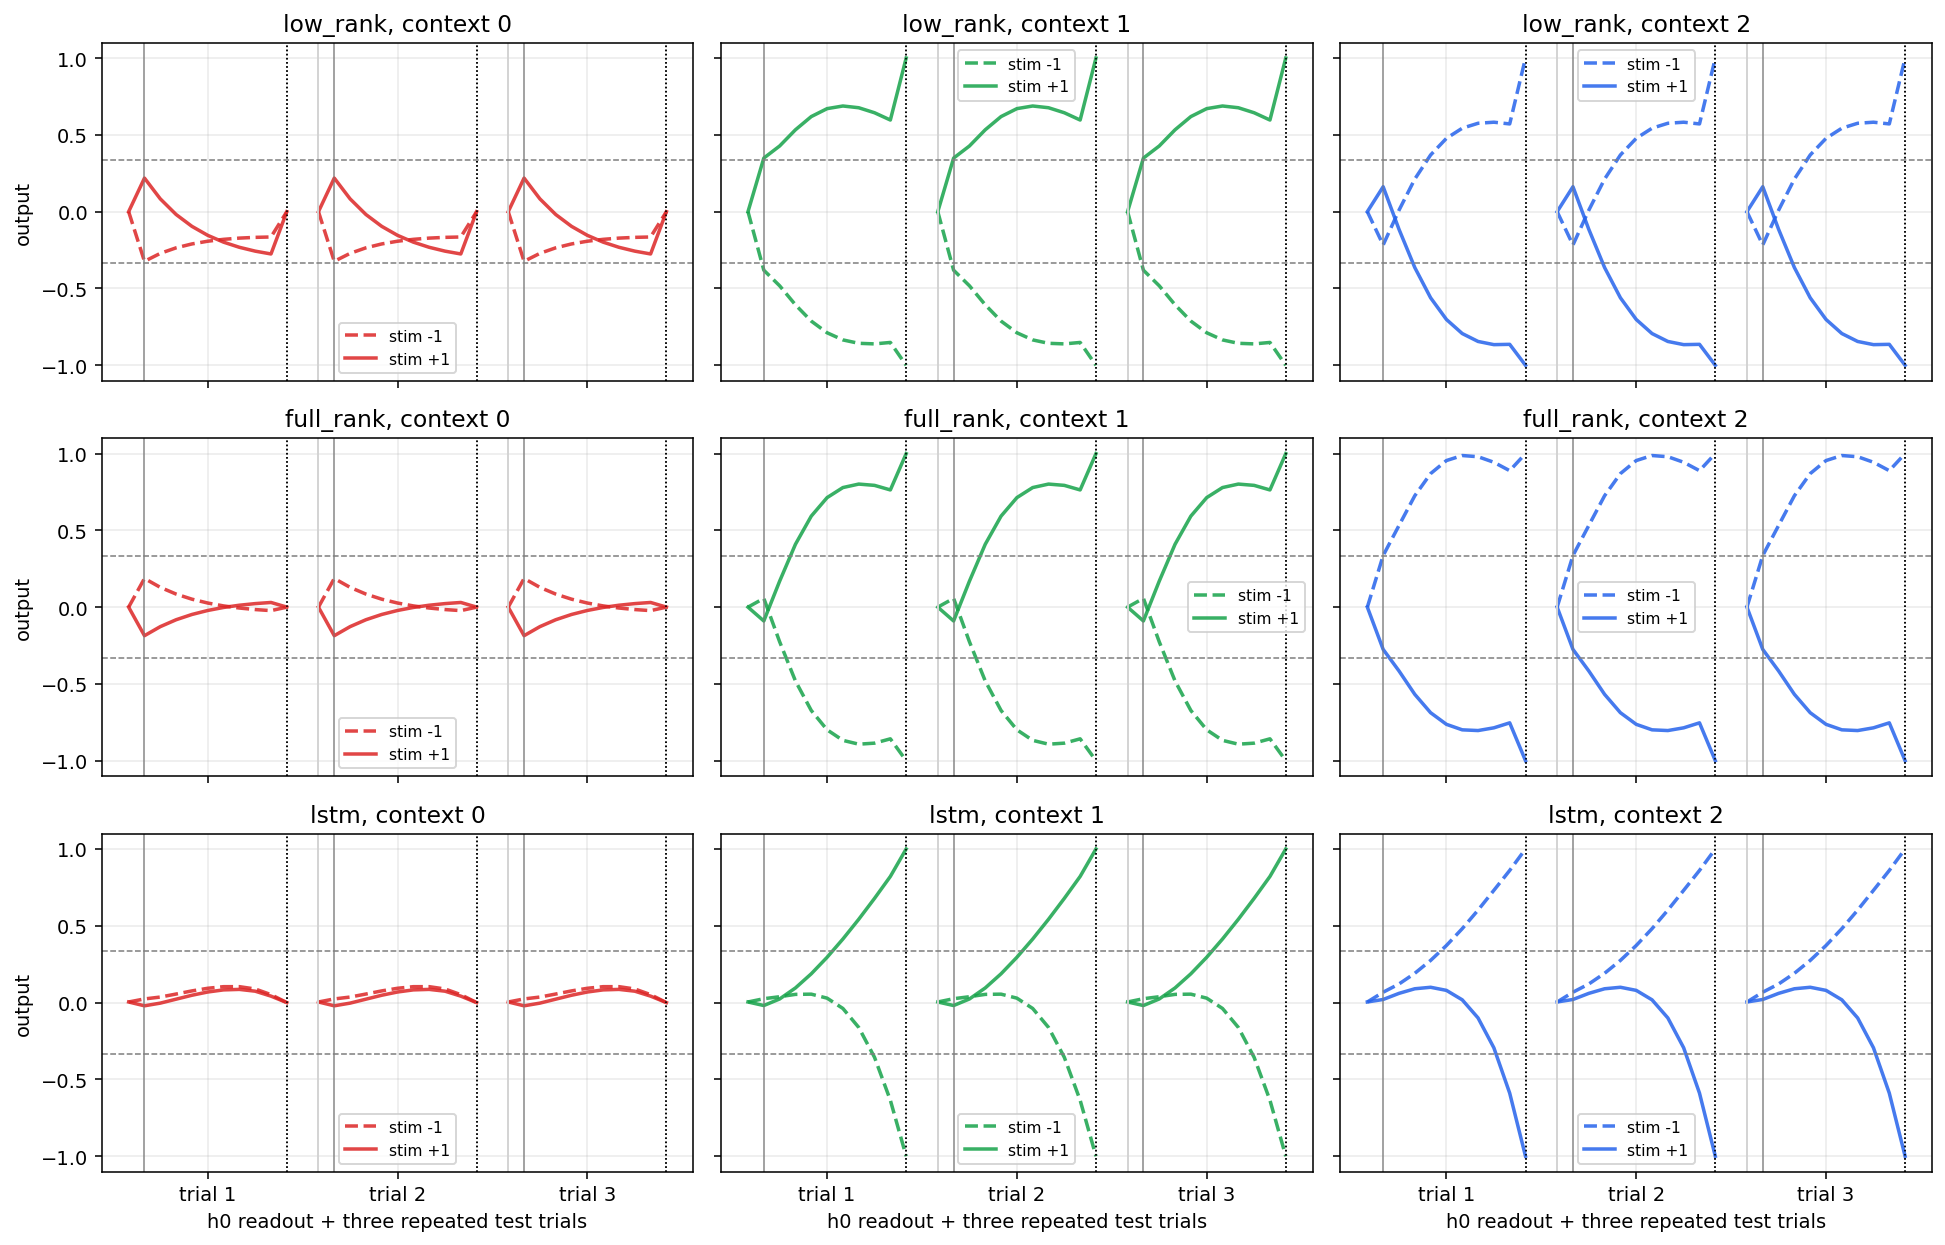

In [20]:
colors = {0: "#dc2626", 1: "#16a34a", 2: "#2563eb"}
linestyles = {-1: "--", 1: "-"}

def initial_readout(model, model_name):
    """Readout from the default initial state h0 before any input."""
    with T.no_grad():
        if model_name == "lstm":
            # For LSTM, default hidden/cell states are zeros.
            h0 = T.zeros(1, 1, model.hidden_size, device=DEVICE)
            y0 = model.readout(h0.squeeze(0))
            return float(y0.squeeze().cpu())

        # For low-rank and full-rank RNNs, read out tanh(h0).
        h0 = model.h0.to(DEVICE)
        rates = T.tanh(h0)
        y0 = rates @ model.W_out.t()
        return float(y0.squeeze().cpu())


trial_len = task.seq_len
gap = 1

# Add one pre-trial timestep at x=-1 for h0 readout.
pre_len = 1
plot_trial_len = trial_len + pre_len
trial_stride = plot_trial_len + gap

trial_x = np.arange(-1, trial_len)
real_trial_x = np.arange(trial_len)
trial_centers = [
    (trial_x.mean() + k * trial_stride)
    for k in range(TEST_REPEATS_PER_CASE)
]

fig, axes = plt.subplots(3, 3, figsize=(14, 9), sharex=True, sharey=True, dpi=140)

for row, (name, res) in enumerate(results.items()):
    outputs = res["outputs"].squeeze(-1).numpy()
    y0 = initial_readout(models[name], name)

    for context_id in range(3):
        ax = axes[row, context_id]

        for stimulus in (-1, 1):
            mask = (
                (contexts.cpu().numpy() == context_id)
                & (stimuli.cpu().numpy() == stimulus)
            )

            trial_indices = np.where(mask)[0][:TEST_REPEATS_PER_CASE]

            for repeat_i, trial_idx in enumerate(trial_indices):
                x = trial_x + repeat_i * trial_stride

                # Prepend h0 readout at t=-1.
                y = np.concatenate([[y0], outputs[trial_idx]])

                label = f"stim {stimulus:+d}" if repeat_i == 0 else None

                ax.plot(
                    x,
                    y,
                    color=colors[context_id],
                    ls=linestyles[stimulus],
                    lw=1.8,
                    alpha=0.85,
                    label=label,
                )

                # Mark stimulus onset t=0.
                ax.axvline(
                    0 + repeat_i * trial_stride,
                    color="grey",
                    ls="-",
                    lw=0.8,
                    alpha=0.6,
                )

                # Mark go cue / decision timestep.
                ax.axvline(
                    task.go_cue_t + repeat_i * trial_stride,
                    color="black",
                    ls=":",
                    lw=0.8,
                )

        for repeat_i in range(1, TEST_REPEATS_PER_CASE):
            ax.axvline(
                repeat_i * trial_stride - gap,
                color="lightgrey",
                lw=1.0,
            )

        ax.axhline(1 / 3, color="grey", ls="--", lw=0.8)
        ax.axhline(-1 / 3, color="grey", ls="--", lw=0.8)

        ax.set_title(f"{name}, context {context_id}")
        ax.set_xticks(
            trial_centers,
            [f"trial {i + 1}" for i in range(TEST_REPEATS_PER_CASE)],
        )

        ax.grid(True, alpha=0.25)

        if row == 2:
            ax.set_xlabel("h0 readout + three repeated test trials")
        if context_id == 0:
            ax.set_ylabel("output")

        ax.legend(fontsize=8)

plt.tight_layout()
plt.show()


## 7. Latent Dynamics: PCA of Hidden States

This is a first mechanistic inspection. For each trained network, hidden states from all 18 test trials and all 10 timesteps are projected onto the top two principal components. Each line is the mean trajectory for one context/stimulus condition.

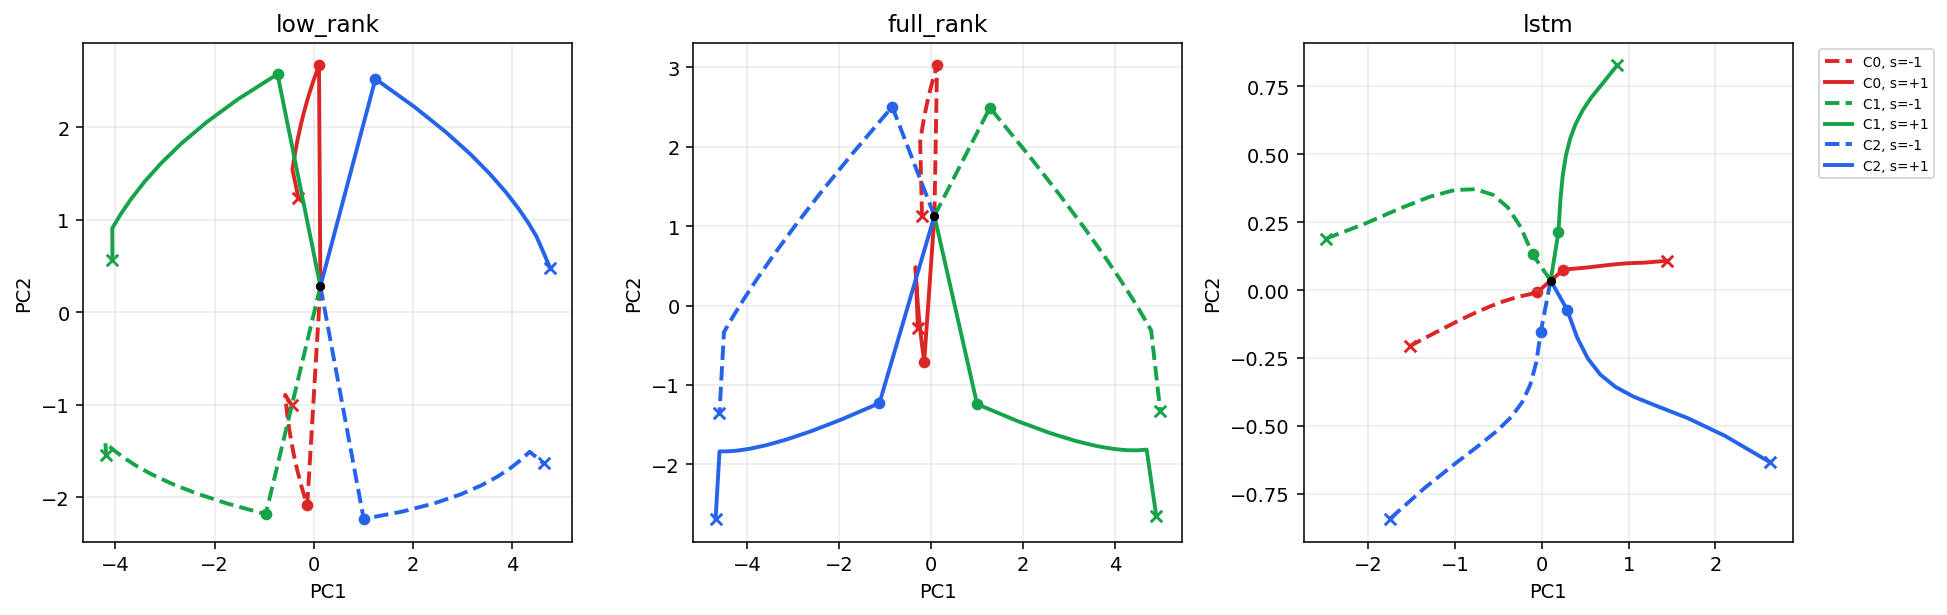

In [21]:
def get_initial_state_for_pca(model, model_name):
    """Return initial hidden state with shape [1, hidden]."""
    with T.no_grad():
        if model_name == "lstm":
            # LSTM starts from zero hidden state by default.
            return T.zeros(1, model.hidden_size).cpu()

        # Low-rank and full-rank RNNs use model.h0.
        return model.h0.detach().cpu()


def pca_project_with_h0(states, h0):
    """
    states: [batch, time, hidden]
    h0:     [1, hidden]

    PCA is fit on both h0 and all trajectory states, then h0 is returned
    in the same PC space as the trajectories.
    """
    X_states = states.reshape(-1, states.shape[-1]).numpy()
    X_h0 = h0.numpy()

    X_all = np.concatenate([X_h0, X_states], axis=0)
    X_mean = X_all.mean(axis=0, keepdims=True)
    X_centered = X_all - X_mean

    _, _, vt = np.linalg.svd(X_centered, full_matrices=False)
    pcs = vt[:2].T

    Z_all = X_centered @ pcs
    Z_h0 = Z_all[0]
    Z_states = Z_all[1:].reshape(states.shape[0], states.shape[1], 2)

    return Z_states, Z_h0


fig, axes = plt.subplots(1, 3, figsize=(14, 4.5), dpi=140)

for ax, (name, res) in zip(axes, results.items()):
    h0 = get_initial_state_for_pca(models[name], name)
    Z, Z_h0 = pca_project_with_h0(res["states"], h0)

    for context_id in range(3):
        for stimulus in (-1, 1):
            mask = (
                (contexts.cpu().numpy() == context_id)
                & (stimuli.cpu().numpy() == stimulus)
            )

            # Average repeated trials after projection.
            traj = Z[mask].mean(axis=0)

            # Prepend projected h0 as the pre-trial initial point.
            traj_with_h0 = np.vstack([Z_h0[None, :], traj])

            ax.plot(
                traj_with_h0[:, 0],
                traj_with_h0[:, 1],
                color=colors[context_id],
                ls=linestyles[stimulus],
                lw=2,
                label=f"C{context_id}, s={stimulus:+d}",
            )

            # h0 point
            ax.scatter(
                traj_with_h0[0, 0],
                traj_with_h0[0, 1],
                color="black",
                marker=".",
                s=45,
                zorder=5,
            )

            # first post-input state
            ax.scatter(
                traj_with_h0[1, 0],
                traj_with_h0[1, 1],
                color=colors[context_id],
                marker="o",
                s=25,
            )

            # final decision state
            ax.scatter(
                traj_with_h0[-1, 0],
                traj_with_h0[-1, 1],
                color=colors[context_id],
                marker="x",
                s=35,
            )

    ax.set_title(name)
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
    ax.grid(True, alpha=0.25)

handles, labels = axes[-1].get_legend_handles_labels()
axes[-1].legend(
    handles[:6],
    labels[:6],
    fontsize=7,
    bbox_to_anchor=(1.04, 1),
    loc="upper left",
)

plt.tight_layout()
plt.show()


### 8.low-rank dynamic

## 8. Low-Rank-Only Analysis: Input Weight Geometry

Now we focus only on the low-rank RNN because its dynamics are simpler and more traceable. This analysis inspects `W_in`, the input-to-hidden matrix. Each column tells us how one input channel drives the hidden population:

`[stimulus, cond_0, cond_1, cond_2, go_cue]`

The heatmap shows all hidden-unit input weights. The corner plot shows pairwise relationships between input channels across hidden units. The selectivity count asks which input channel has the largest absolute incoming weight for each hidden unit.

W_in shape: (256, 5)
Columns: ['stimulus', 'cond_0', 'cond_1', 'cond_2', 'go_cue']


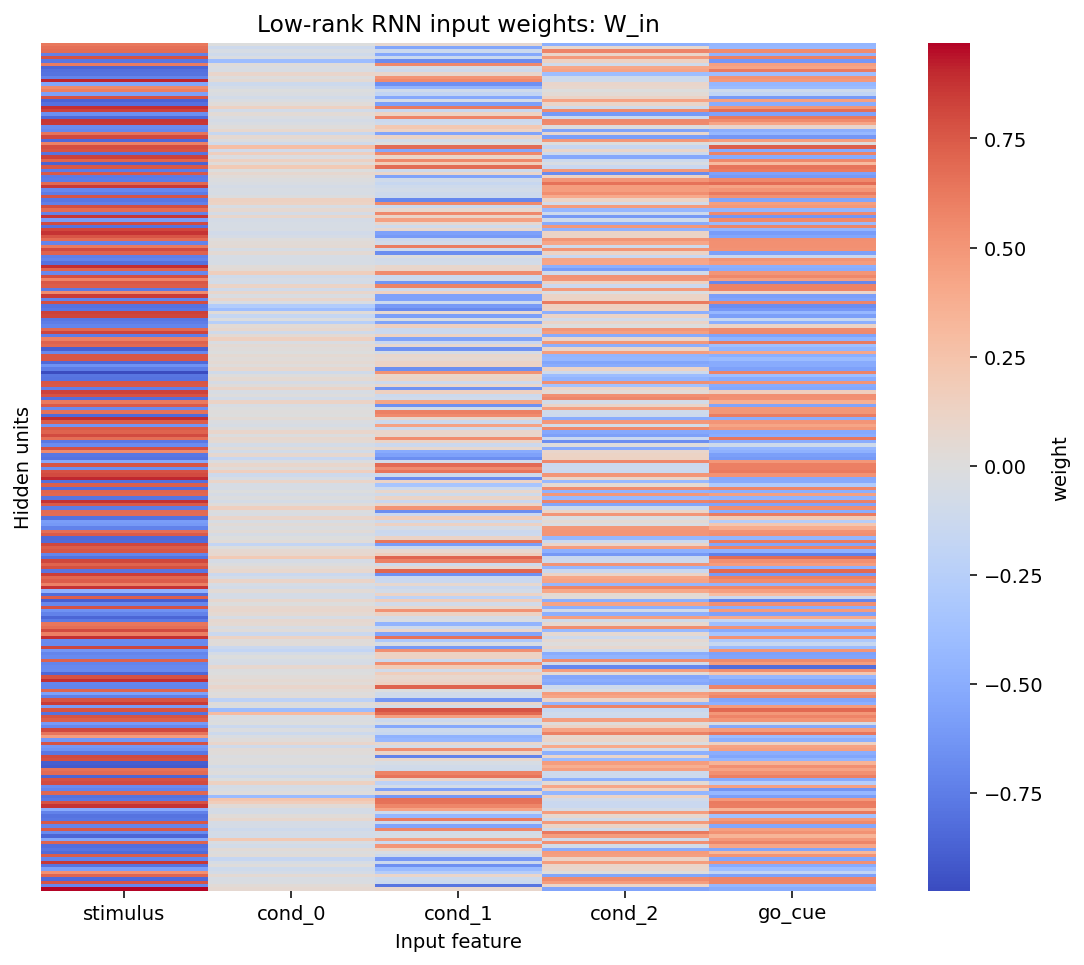

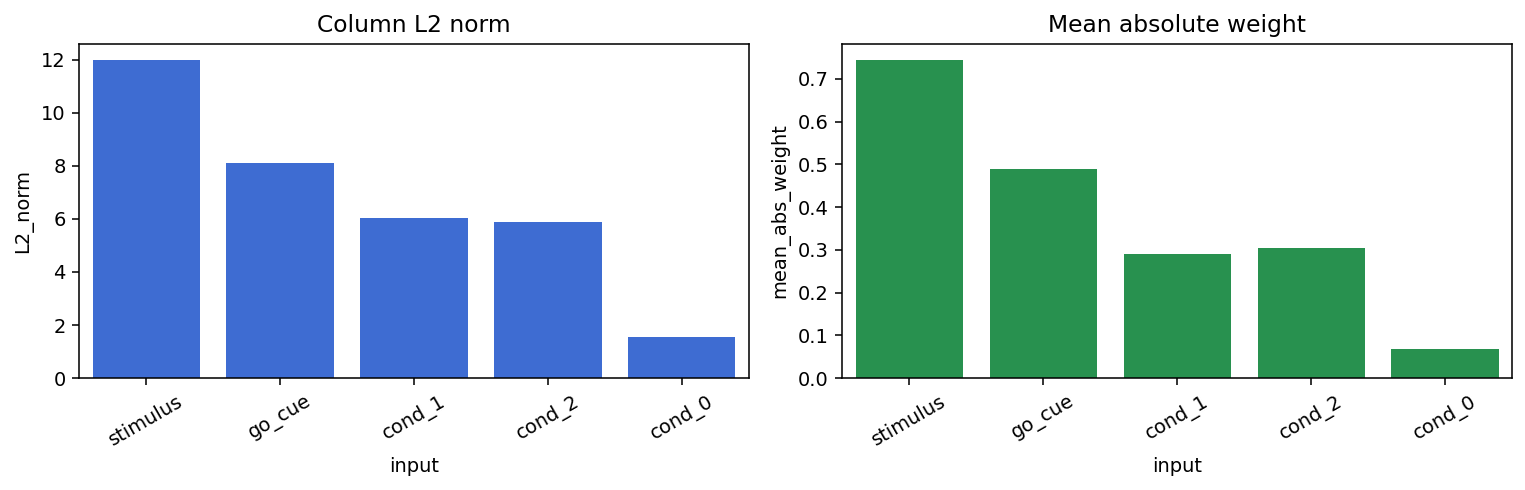

,input,L2_norm,mean_abs_weight
0,stimulus,12.011103,0.745389
4,go_cue,8.099195,0.488510
2,cond_1,6.021575,0.290515
3,cond_2,5.894720,0.303771
1,cond_0,1.540682,0.068192


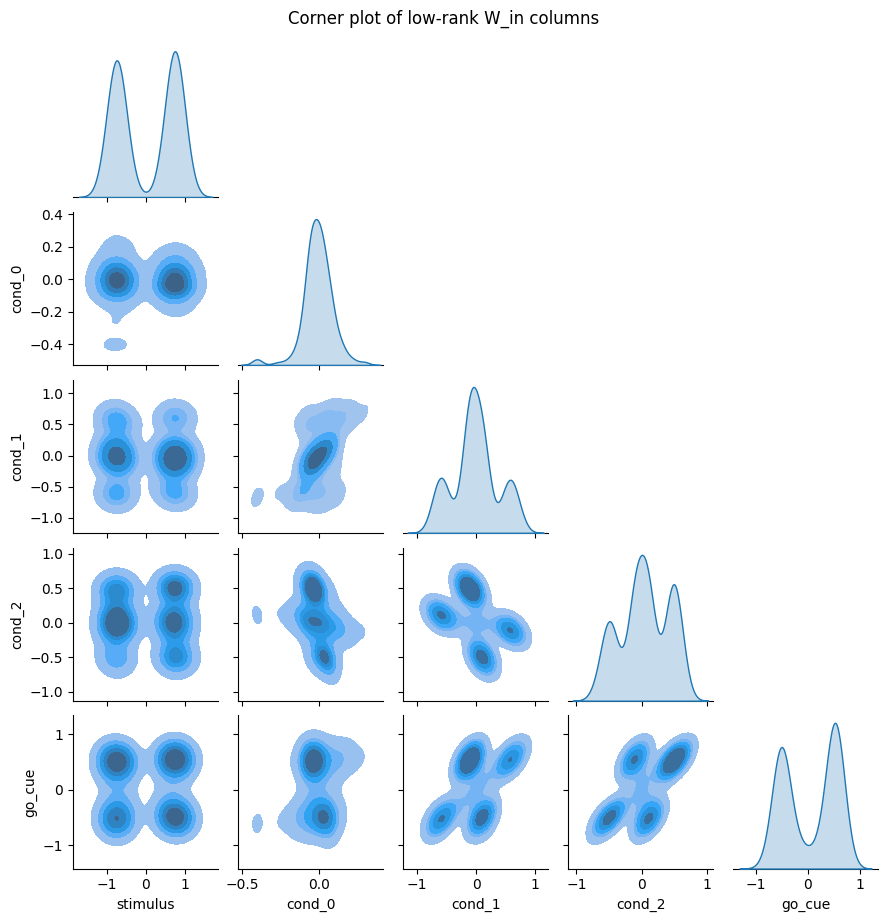

Selectivity distribution: largest absolute W_in column per hidden unit


,input,count,fraction
0,stimulus,249,0.972656
1,cond_0,0,0.000000
2,cond_1,4,0.015625
3,cond_2,1,0.003906
4,go_cue,2,0.007812


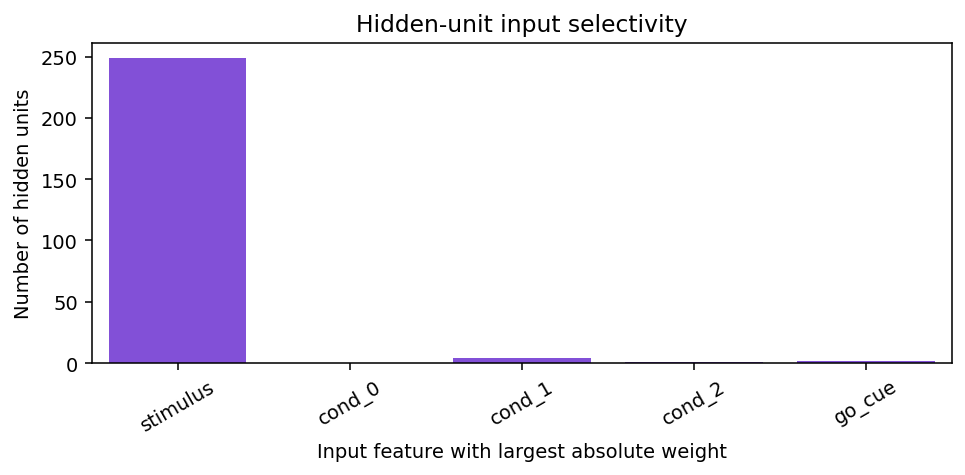

In [23]:
import seaborn as sns

LOW_RANK_COLUMN_NAMES = ["stimulus", "cond_0", "cond_1", "cond_2", "go_cue"]


def extract_low_rank_state_dict():
    """Return the trained low-rank state dict from the loaded checkpoint."""
    if "model_state_dict" in checkpoints["low_rank"]:
        return checkpoints["low_rank"]["model_state_dict"]
    if "state_dict" in checkpoints["low_rank"]:
        return checkpoints["low_rank"]["state_dict"]
    raise KeyError("Could not find low-rank model state dict in checkpoint.")


def analyze_low_rank_w_in(state_dict, column_names=LOW_RANK_COLUMN_NAMES):
    """Analyze input weights of the trained homework low-rank RNN."""
    if "W_in" not in state_dict:
        raise KeyError("Current homework low-rank model should contain W_in in its state dict.")

    W_in = state_dict["W_in"]
    if isinstance(W_in, T.Tensor):
        W_in = W_in.detach().cpu().numpy()

    if W_in.shape[1] != len(column_names):
        raise ValueError(f"Expected {len(column_names)} input columns, got W_in shape {W_in.shape}.")

    print("W_in shape:", W_in.shape)
    print("Columns:", column_names)

    # 1. Heatmap across hidden units and input features.
    plt.figure(figsize=(8, 7), dpi=140)
    sns.heatmap(
        W_in,
        cmap="coolwarm",
        center=0,
        xticklabels=column_names,
        yticklabels=False,
        cbar_kws={"label": "weight"},
    )
    plt.title("Low-rank RNN input weights: W_in")
    plt.xlabel("Input feature")
    plt.ylabel("Hidden units")
    plt.tight_layout()
    plt.show()

    # 2. Column norm summary.
    col_norms = np.linalg.norm(W_in, axis=0)
    col_abs_mean = np.mean(np.abs(W_in), axis=0)
    summary = pd.DataFrame({
        "input": column_names,
        "L2_norm": col_norms,
        "mean_abs_weight": col_abs_mean,
    }).sort_values("L2_norm", ascending=False)

    fig, axes = plt.subplots(1, 2, figsize=(11, 3.6), dpi=140)
    sns.barplot(data=summary, x="input", y="L2_norm", ax=axes[0], color="#2563eb")
    axes[0].set_title("Column L2 norm")
    axes[0].tick_params(axis="x", rotation=30)
    sns.barplot(data=summary, x="input", y="mean_abs_weight", ax=axes[1], color="#16a34a")
    axes[1].set_title("Mean absolute weight")
    axes[1].tick_params(axis="x", rotation=30)
    plt.tight_layout()
    plt.show()

    display(summary)

    # 3. Corner plot of hidden-unit input weights.
    df = pd.DataFrame(W_in, columns=column_names)
    g = sns.pairplot(
        data=df,
        diag_kind="kde",
        kind="kde",
        corner=True,
        height=1.8,
        plot_kws={"fill": True, "levels": 6, "thresh": 0.05},
    )
    g.fig.suptitle("Corner plot of low-rank W_in columns", y=1.02)
    plt.show()

    # 4. Selectivity: largest absolute input weight for each hidden unit.
    abs_w = np.abs(W_in)
    max_idx = np.argmax(abs_w, axis=1)
    unique, counts = np.unique(max_idx, return_counts=True)
    selectivity = pd.DataFrame({"input": column_names, "count": 0})
    for idx, count in zip(unique, counts):
        selectivity.loc[selectivity["input"] == column_names[idx], "count"] = int(count)
    selectivity["fraction"] = selectivity["count"] / W_in.shape[0]

    print("Selectivity distribution: largest absolute W_in column per hidden unit")
    display(selectivity)

    plt.figure(figsize=(7, 3.5), dpi=140)
    sns.barplot(data=selectivity, x="input", y="count", color="#7c3aed")
    plt.title("Hidden-unit input selectivity")
    plt.xlabel("Input feature with largest absolute weight")
    plt.ylabel("Number of hidden units")
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()

    return W_in, summary, selectivity


low_rank_state_dict = extract_low_rank_state_dict()
W_in_low_rank, W_in_summary, W_in_selectivity = analyze_low_rank_w_in(low_rank_state_dict)

,direction,group,dot,cosine,abs_cosine
0,stimulus,input,1.354825,0.016004,0.016004
1,cond_0,input,-0.268152,-0.024694,0.024694
2,cond_1,input,-0.091991,-0.002167,0.002167
3,cond_2,input,-0.146458,-0.003525,0.003525
4,go_cue,input,1.009338,0.017681,0.017681
5,"m = U[:,0]",recurrent,-2.183308,-0.025295,0.025295
6,"n = V[:,0]",recurrent,-0.400046,-0.004442,0.004442


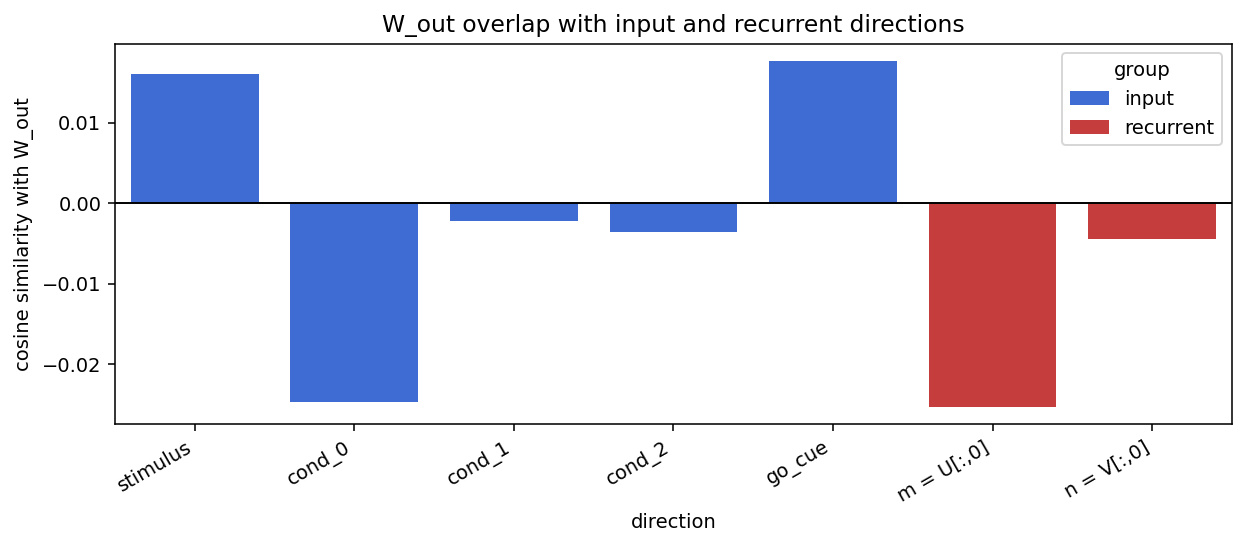

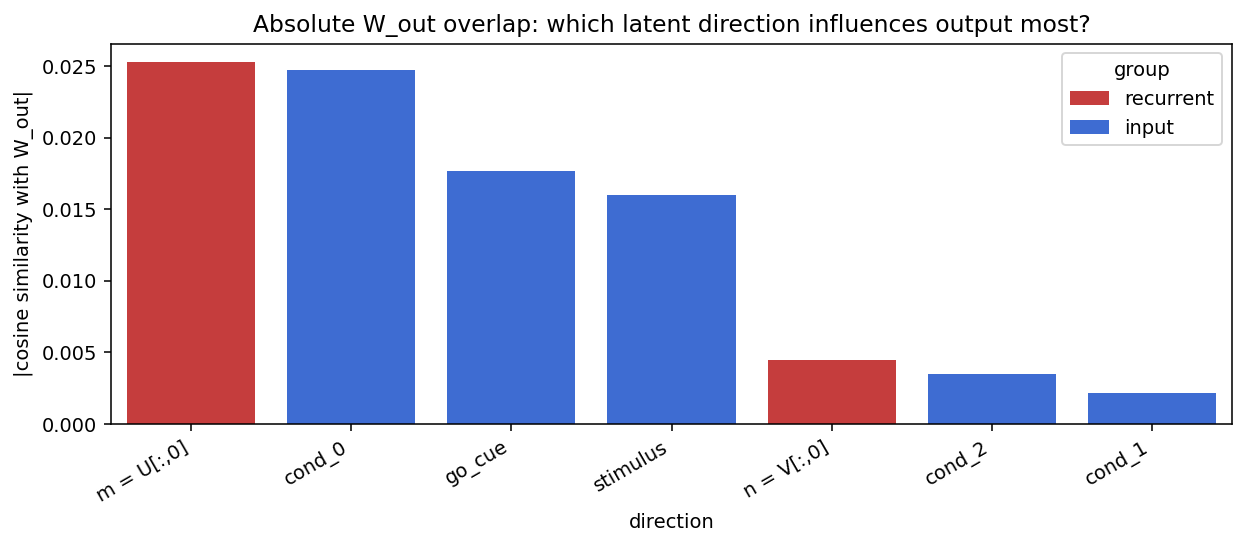

In [25]:
low_rank_model = models["low_rank"]

W_in = low_rank_model.W_in.detach().cpu().numpy()
U = low_rank_model.U.detach().cpu().numpy()
V = low_rank_model.V.detach().cpu().numpy()
W_out = low_rank_model.W_out.detach().cpu().numpy()

# For rank-1 low-rank RNN:
# recurrent matrix is approximately U @ V.T
# In low-rank theory notation, one often thinks of:
# m = U[:, 0] as the output/recurrent direction
# n = V[:, 0] as the input/readout-to-latent direction
m = U[:, 0]
n = V[:, 0]
w_out = W_out[0]

input_names = ["stimulus", "cond_0", "cond_1", "cond_2", "go_cue"]

# Normalize helper
def cosine(a, b):
    a = np.asarray(a)
    b = np.asarray(b)
    return np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b) + 1e-12)

# Compute overlaps between W_out and each task/input direction
rows = []

# W_out with input columns
for i, name in enumerate(input_names):
    w_in_col = W_in[:, i]
    rows.append({
        "direction": name,
        "group": "input",
        "dot": np.dot(w_out, w_in_col),
        "cosine": cosine(w_out, w_in_col),
        "abs_cosine": abs(cosine(w_out, w_in_col)),
    })

# W_out with recurrent low-rank directions
rows += [
    {
        "direction": "m = U[:,0]",
        "group": "recurrent",
        "dot": np.dot(w_out, m),
        "cosine": cosine(w_out, m),
        "abs_cosine": abs(cosine(w_out, m)),
    },
    {
        "direction": "n = V[:,0]",
        "group": "recurrent",
        "dot": np.dot(w_out, n),
        "cosine": cosine(w_out, n),
        "abs_cosine": abs(cosine(w_out, n)),
    },
]

overlap_df = pd.DataFrame(rows)
display(overlap_df)

# Plot signed cosine overlap
plt.figure(figsize=(9, 4), dpi=140)
sns.barplot(
    data=overlap_df,
    x="direction",
    y="cosine",
    hue="group",
    dodge=False,
    palette={"input": "#2563eb", "recurrent": "#dc2626"},
)
plt.axhline(0, color="black", lw=1)
plt.title("W_out overlap with input and recurrent directions")
plt.ylabel("cosine similarity with W_out")
plt.xlabel("direction")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

# Plot absolute cosine overlap
plt.figure(figsize=(9, 4), dpi=140)
sns.barplot(
    data=overlap_df.sort_values("abs_cosine", ascending=False),
    x="direction",
    y="abs_cosine",
    hue="group",
    dodge=False,
    palette={"input": "#2563eb", "recurrent": "#dc2626"},
)
plt.title("Absolute W_out overlap: which latent direction influences output most?")
plt.ylabel("|cosine similarity with W_out|")
plt.xlabel("direction")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

In [37]:

def gram_schmidt(X, rank):
    O = X.copy()  # np.zeros(X.shape)
    for i in range(X.shape[1]):
        # orthogonalization（正交化）
        vector = X[:, i]
        space = O[:, :i]
        projection = vector @ space
        vector = vector - np.sum(projection * space, axis=1)
        # normalization（归一化）
        norm = np.sqrt(vector @ vector)
        vector /= abs(norm) < 1e-8 and 1 or norm

        O[:, i] = vector
    return O



In [ ]:

import numpy as np
import torch as T


def make_gonogo_input_one_trial(context_id, stimulus, seq_len=10, context_mode="tonic"):
    """
    Full task input with channels:
    [stimulus, cond_0, cond_1, cond_2, go_cue]
    """
    u = np.zeros((seq_len, 5), dtype=np.float32)

    if context_mode == "tonic":
        u[:, 1 + context_id] = 1.0
        u[0, 0] = float(stimulus)
    elif context_mode == "brief":
        u[0, 1 + context_id] = 1.0
        u[1, 0] = float(stimulus)
    else:
        raise ValueError("context_mode must be 'tonic' or 'brief'.")

    u[-1, 4] = 1.0
    return u


def build_context_specific_gs_basis_from_low_rank(model, context_id):
    """
    Build a context-specific reduced basis.

    Because context is one-hot, for a fixed context only these input channels
    can be active:

        stimulus, cond_context_id, go_cue

    So for rank-1, the reduced subspace is:

        [U, W_stimulus, W_context, W_go_cue]

    dimension = 1 + 3 = 4.

    For rank-R, dimension = R + 3.
    """
    U = model.U.detach().cpu().numpy()          # [N, rank]
    V = model.V.detach().cpu().numpy()          # [N, rank]
    W_in = model.W_in.detach().cpu().numpy()    # [N, 5]
    W_out = model.W_out.detach().cpu().numpy()  # [1, N]

    rank = U.shape[1]

    active_input_indices = [0, 1 + context_id, 4]
    active_input_names = [
        "stimulus",
        f"cond_{context_id}",
        "go_cue",
    ]

    W_in_active = W_in[:, active_input_indices]  # [N, 3]

    # Gram-Schmidt over only the directions that can be active in this context.
    direction_vector = np.hstack([U, W_in_active])
    Q = gram_schmidt(direction_vector, 0)

    U_orth = Q[:, :rank]
    W_in_active_bot = Q[:, rank:]

    return {
        "U": U,
        "V": V,
        "W_in": W_in,
        "W_in_active": W_in_active,
        "W_out": W_out,
        "Q": Q,
        "U_orth": U_orth,
        "W_in_active_bot": W_in_active_bot,
        "rank": rank,
        "active_input_indices": active_input_indices,
        "active_input_names": active_input_names,
    }


def simulate_low_rank_gonogo_one_trial_subspace(
    model,
    context_id,
    stimulus,
    seq_len=10,
    context_mode="tonic",
    x0=None,
):
    """
    Context-specific subspace simulation.

    Uses only the active subspace for the tested context:

        [U, W_stimulus, W_context, W_go_cue]

    For rank-1 this gives a 4D subspace.

    Returns both:
        post-update trajectories: match model.forward()
        pre-update trajectories: useful for plotting h0
    """
    basis = build_context_specific_gs_basis_from_low_rank(model, context_id)

    U = basis["U"]
    V = basis["V"]
    W_in_active = basis["W_in_active"]
    W_out = basis["W_out"][0]
    Q = basis["Q"]

    N = model.hidden_size
    rank = basis["rank"]
    alpha = model.alpha

    if x0 is None:
        x = model.h0.detach().cpu().numpy().reshape(N).copy()
    else:
        x = np.asarray(x0).reshape(N).copy()

    # Project initial state into context-specific subspace.
    # For current homework models h0 is zero, so this is exact.
    kappa = Q.T @ x

    u_full = make_gonogo_input_one_trial(
        context_id=context_id,
        stimulus=stimulus,
        seq_len=seq_len,
        context_mode=context_mode,
    )

    active_idx = basis["active_input_indices"]
    u_active = u_full[:, active_idx]  # [T, 3]

    # Post-update quantities: directly comparable with model.forward().
    x_traj = np.zeros((seq_len, N), dtype=np.float32)
    phi_traj = np.zeros((seq_len, N), dtype=np.float32)
    readout_traj = np.zeros(seq_len, dtype=np.float32)
    kappa_traj = np.zeros((seq_len, Q.shape[1]), dtype=np.float32)

    # Pre-update quantities: useful for showing h0.
    x_pre_traj = np.zeros((seq_len, N), dtype=np.float32)
    phi_pre_traj = np.zeros((seq_len, N), dtype=np.float32)
    pre_readout_traj = np.zeros(seq_len, dtype=np.float32)
    kappa_pre_traj = np.zeros((seq_len, Q.shape[1]), dtype=np.float32)

    feedback_traj = np.zeros((seq_len, rank), dtype=np.float32) 
    input_drive_traj = np.zeros((seq_len, Q.shape[1]), dtype=np.float32)

    QTU = Q.T @ U                  # [rank + 3, rank]
    QTW_active = Q.T @ W_in_active # [rank + 3, 3]

    for t in range(seq_len):
        # ----- pre-update state -----
        x_pre = Q @ kappa
        phi_pre = np.tanh(x_pre)

        x_pre_traj[t] = x_pre
        phi_pre_traj[t] = phi_pre
        pre_readout_traj[t] = np.dot(W_out, phi_pre)
        kappa_pre_traj[t] = kappa

        # ----- dynamics projected into context-specific subspace -----
        feedback = (V.T @ phi_pre) / float(N)      # [rank]
        input_drive = QTW_active @ u_active[t]     # [rank + 3]

        d_kappa = -kappa + (QTU @ feedback) + input_drive

        feedback_traj[t] = feedback
        input_drive_traj[t] = input_drive

        # ----- Euler update -----
        kappa = kappa + alpha * d_kappa

        # ----- post-update state, matching model.forward output[t] -----
        x_post = Q @ kappa
        phi_post = np.tanh(x_post)
        readout_post = np.dot(W_out, phi_post)

        x_traj[t] = x_post
        phi_traj[t] = phi_post
        readout_traj[t] = readout_post
        kappa_traj[t] = kappa

    active_input_names = basis["active_input_names"]

    return {
        "context_id": context_id,
        "stimulus": stimulus,
        "context_mode": context_mode,

        # Full and active input sequences
        "u_t": u_full,
        "u_active": u_active,
        "input_names": ["stimulus", "cond_0", "cond_1", "cond_2", "go_cue"],
        "active_input_indices": basis["active_input_indices"],
        "active_input_names": active_input_names,

        # Basis and weights
        "Q": Q,
        "U": U,
        "V": V,
        "W_in": basis["W_in"],
        "W_in_active": W_in_active,
        "W_out": W_out,
        "U_orth": basis["U_orth"],
        "W_in_bot": basis["W_in_active_bot"],
        "W_in_active_bot": basis["W_in_active_bot"],

        # post-update, matches forward()
        "x_traj": x_traj,
        "phi_traj": phi_traj,
        "readout_traj": readout_traj,
        "kappa_traj": kappa_traj,
        "kappa_rec_traj": kappa_traj[:, :rank],
        "kappa_s_traj": kappa_traj[:, rank:],

        # pre-update, useful for showing h0
        "x_pre_traj": x_pre_traj,
        "phi_pre_traj": phi_pre_traj,
        "pre_readout_traj": pre_readout_traj,
        "kappa_pre_traj": kappa_pre_traj,
        "kappa_rec_pre_traj": kappa_pre_traj[:, :rank],
        "kappa_s_pre_traj": kappa_pre_traj[:, rank:],

        # update terms
        "feedback_traj": feedback_traj,
        "input_drive_traj": input_drive_traj,

        "rank": rank,
        "subspace_dim": Q.shape[1],
    }


In [65]:
def compare_forward_vs_subspace(
    model,
    context_id=1,
    stimulus=1,
    seq_len=10,
    context_mode="tonic",
):
    model.eval()

    u_np = make_gonogo_input_one_trial(
        context_id=context_id,
        stimulus=stimulus,
        seq_len=seq_len,
        context_mode=context_mode,
    )

    x_input = T.tensor(
        u_np,
        dtype=T.float32,
        device=next(model.parameters()).device,
    ).unsqueeze(0)

    with T.no_grad():
        real_outputs, _ = model(x_input, return_states=True)

    real_readout = real_outputs[0, :, 0].detach().cpu().numpy()

    sim = simulate_low_rank_gonogo_one_trial_subspace(
        model=model,
        context_id=context_id,
        stimulus=stimulus,
        seq_len=seq_len,
        context_mode=context_mode,
    )

    sim_readout = sim["readout_traj"]

    print("subspace dim:", sim["subspace_dim"])
    print("active inputs:", sim["active_input_names"])
    print("max abs readout diff:", np.max(np.abs(real_readout - sim_readout)))
    print("real:", np.round(real_readout, 5))
    print("sim :", np.round(sim_readout, 5))

    t = np.arange(seq_len)

    plt.figure(figsize=(7, 4), dpi=140)
    plt.plot(t, real_readout, "o-", label="actual forward()")
    plt.plot(t, sim_readout, "s--", label="context-specific subspace sim")
    plt.axhline(1 / 3, color="grey", ls="--", lw=0.8)
    plt.axhline(-1 / 3, color="grey", ls="--", lw=0.8)
    plt.title(f"context {context_id}, stimulus {stimulus:+d}")
    plt.xlabel("timestep")
    plt.ylabel("readout")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

    return sim


subspace dim: 4
active inputs: ['stimulus', 'cond_1', 'go_cue']
max abs readout diff: 8.34465e-07
real: [0.34871 0.42743 0.53293 0.61894 0.67057 0.68779 0.67645 0.64377 0.59647
 1.     ]
sim : [0.34871 0.42743 0.53293 0.61894 0.67057 0.68779 0.67645 0.64377 0.59647
 1.     ]


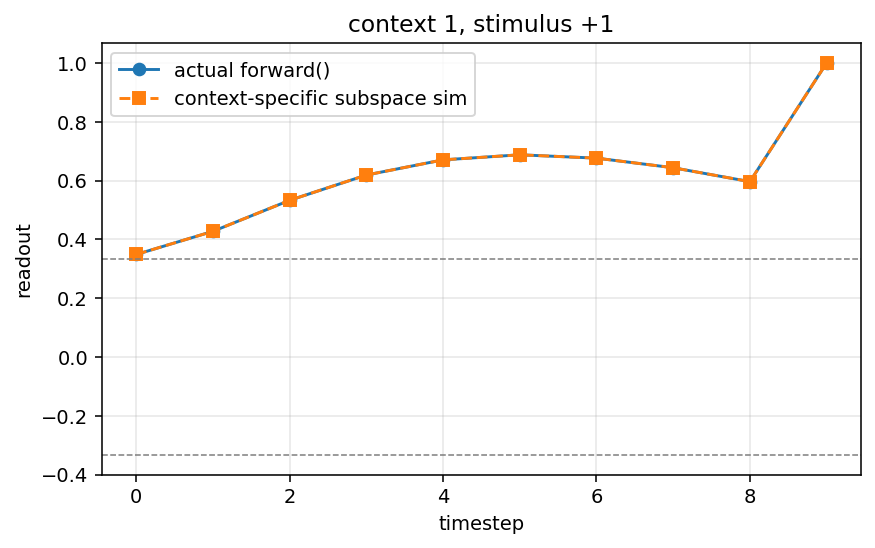

In [66]:
sim = compare_forward_vs_subspace(
    model=models["low_rank"],
    context_id=1,
    stimulus=1,
    seq_len=10,
    context_mode="tonic",
)


In [ ]:
def compute_low_rank_flow_field_2d_single_context(
    sim,
    model=None,
    flow_t=5,
    fixed_t=None,
    kappa_rec_range=(-2, 2),
    kappa_context_range=(-2, 2),
    grid_n=35,
    fixed_from="pre",
    alpha=None,
):
    """
    2D flow field for one context only.

    x-axis: kappa_rec0
    y-axis: kappa_own_context
    """

    if fixed_t is None:
        fixed_t = flow_t

    if alpha is None:
        if model is not None:
            alpha = float(model.alpha)
        else:
            alpha = 0.2

    Q = sim["Q"]
    U = sim["U"]
    V = sim["V"]
    W_in_active = sim["W_in_active"]
    W_out = sim["W_out"].reshape(-1)

    rank = sim["rank"]
    hidden_size = Q.shape[0]

    active_names = sim["active_input_names"]
    own_context_name = f"cond_{sim['context_id']}"

    x_idx = 0

    if own_context_name in active_names:
        own_context_active_idx = active_names.index(own_context_name)
    else:
        # fallback for active_names = ["stimulus", "own_context", "go_cue"]
        own_context_active_idx = 1

    y_idx = rank + own_context_active_idx

    if fixed_from == "pre":
        fixed_kappa = sim["kappa_pre_traj"][fixed_t].copy()
    elif fixed_from == "post":
        fixed_kappa = sim["kappa_traj"][fixed_t].copy()
    else:
        raise ValueError("fixed_from must be 'pre' or 'post'.")

    xs = np.linspace(kappa_rec_range[0], kappa_rec_range[1], grid_n)
    ys = np.linspace(kappa_context_range[0], kappa_context_range[1], grid_n)
    X, Y = np.meshgrid(xs, ys)

    K = np.tile(fixed_kappa[None, :], (grid_n * grid_n, 1))
    K[:, x_idx] = X.reshape(-1)
    K[:, y_idx] = Y.reshape(-1)

    H = K @ Q.T
    Phi = np.tanh(H)

    readout = Phi @ W_out

    feedback = (Phi @ V) / float(hidden_size)
    recurrent_drive = feedback @ (Q.T @ U).T

    if "u_active" in sim:
        u_active_t = sim["u_active"][flow_t]
    else:
        active_idx = sim["active_input_indices"]
        u_active_t = sim["u_t"][flow_t, active_idx]

    input_drive = (Q.T @ W_in_active) @ u_active_t

    dK = -K + recurrent_drive + input_drive[None, :]
    update = alpha * dK

    Ux = update[:, x_idx].reshape(grid_n, grid_n)
    Uy = update[:, y_idx].reshape(grid_n, grid_n)
    speed = np.sqrt(Ux**2 + Uy**2)

    return {
        "X": X,
        "Y": Y,
        "Ux": Ux,
        "Uy": Uy,
        "speed": speed,
        "readout": readout.reshape(grid_n, grid_n),
        "x_idx": x_idx,
        "y_idx": y_idx,
        "flow_t": flow_t,
        "fixed_t": fixed_t,
        "fixed_from": fixed_from,
        "u_active_t": u_active_t,
        "own_context_name": own_context_name,
    }


def plot_one_context_flow_field(
    sims,
    context_id=0,
    model=None,
    flow_t=5,
    fixed_t=None,
    kappa_rec_range=(-2, 2),
    kappa_context_range=(-2, 2),
    grid_n=60,
    fixed_from="pre",
    readout_clim=(-1.05, 1.05),
    figsize=(7.2, 6.2),
    title="Local dynamics",
    title_fontsize=18,
    label_fontsize=22,
    tick_fontsize=18,
    cbar_fontsize=17,
    stream_density=1.25,
    stream_linewidth=1.4,
):
    """
    Slide-ready flow-field plot for one selected context.

    Background color: readout value.
    White streamlines: local update direction.
    Black curve: actual simulated trajectory.
    """

    sim = sims[context_id]

    field = compute_low_rank_flow_field_2d_single_context(
        sim=sim,
        model=model,
        flow_t=flow_t,
        fixed_t=fixed_t,
        kappa_rec_range=kappa_rec_range,
        kappa_context_range=kappa_context_range,
        grid_n=grid_n,
        fixed_from=fixed_from,
    )

    X = field["X"]
    Y = field["Y"]
    Ux = field["Ux"]
    Uy = field["Uy"]
    readout = field["readout"]

    x_idx = field["x_idx"]
    y_idx = field["y_idx"]

    fig, ax = plt.subplots(1, 1, figsize=figsize, dpi=160)

    # Background: readout value
    cf = ax.contourf(
        X,
        Y,
        readout,
        levels=60,
        cmap="coolwarm",
        vmin=readout_clim[0],
        vmax=readout_clim[1],
        alpha=0.92,
    )

    # Decision/readout threshold contours
    ax.contour(
        X,
        Y,
        readout,
        levels=[-1 / 3, 1 / 3],
        colors="black",
        linewidths=1.6,
        linestyles="--",
        alpha=0.85,
    )

    # Streamline-style flow arrows, common for dynamical systems plots.
    ax.streamplot(
        X,
        Y,
        Ux,
        Uy,
        color="white",
        density=stream_density,
        linewidth=stream_linewidth,
        arrowsize=1.15,
        arrowstyle="->",
        minlength=0.08,
        maxlength=4.0,
        integration_direction="both",
        zorder=3,
        broken_streamlines=True,
    )

    # Actual simulated trajectory, including h0 as the first point.
    traj = np.vstack([
        sim["kappa_pre_traj"][0],
        sim["kappa_traj"],
    ])

    ax.plot(
        traj[:, x_idx],
        traj[:, y_idx],
        color="black",
        lw=3.0,
        marker="o",
        ms=5.0,
        markerfacecolor="black",
        markeredgecolor="black",
        zorder=5,
    )

    # h0
    ax.scatter(
        traj[0, x_idx],
        traj[0, y_idx],
        color="white",
        edgecolor="black",
        linewidth=1.8,
        s=100,
        zorder=6,
    )

    # final state
    ax.scatter(
        traj[-1, x_idx],
        traj[-1, y_idx],
        color="#facc15",
        edgecolor="black",
        linewidth=1.8,
        marker="X",
        s=130,
        zorder=7,
    )

    ax.axhline(0, color="black", lw=1.0, alpha=0.35)
    ax.axvline(0, color="black", lw=1.0, alpha=0.35)

    ax.set_xlim(kappa_rec_range)
    ax.set_ylim(kappa_context_range)

    ax.set_xlabel(r"$\kappa_{rec0}$", fontsize=label_fontsize)
    ax.set_ylabel(r"$\kappa_{context}$", fontsize=label_fontsize)

    ax.set_title(title, fontsize=title_fontsize, pad=14)

    ax.tick_params(axis="both", labelsize=tick_fontsize, width=1.4, length=5)

    for spine in ax.spines.values():
        spine.set_linewidth(1.4)

    ax.grid(True, alpha=0.18, color="white", linewidth=0.8)
    ax.set_aspect("equal", adjustable="box")

    cbar = fig.colorbar(
        cf,
        ax=ax,
        shrink=0.88,
        pad=0.035,
        aspect=24,
    )
    cbar.set_label("readout value", fontsize=cbar_fontsize)
    cbar.ax.tick_params(labelsize=tick_fontsize)

    plt.tight_layout()
    plt.show()


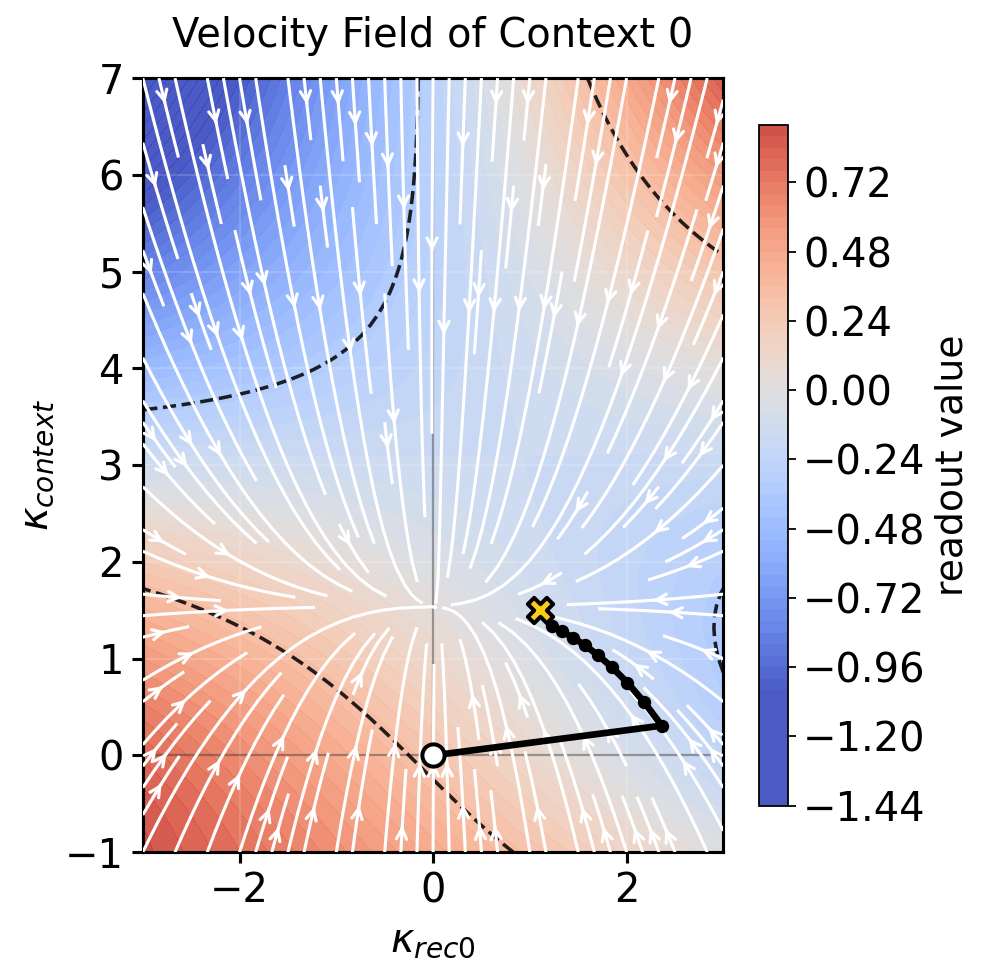

In [ ]:
sims_stim1 = run_context_comparison_sims(
    models["low_rank"],
    stimulus=1,
    seq_len=10,
    context_mode="tonic",
)

plot_one_context_flow_field(
    sims=sims_stim1,
    context_id=2,
    model=models["low_rank"],
    flow_t=5,
    fixed_t=5,
    kappa_rec_range=(-3, 3),
    kappa_context_range=(-1, 7),
    grid_n=70,
    title="Velocity Field of Context 0",
)


In [114]:
import numpy as np
import matplotlib.pyplot as plt


def bootstrap_mean_ci_matrix(x, n_boot=1000, ci=95, rng=None):
    """
    Bootstrap mean CI over axis 0.

    x shape: [num_samples, num_grid_points]
    """
    x = np.asarray(x)

    if x.shape[0] == 1:
        mean = x[0]
        return mean, mean, mean

    if rng is None:
        rng = np.random.default_rng(12345)

    n = x.shape[0]
    boots = []

    for _ in range(n_boot):
        idx = rng.integers(0, n, size=n)
        boots.append(x[idx].mean(axis=0))

    boots = np.stack(boots, axis=0)

    mean = x.mean(axis=0)
    lo = np.percentile(boots, (100 - ci) / 2, axis=0)
    hi = np.percentile(boots, 100 - (100 - ci) / 2, axis=0)

    return mean, lo, hi


def compute_dz_dkappa_rec_curve(
    sim,
    kappa_rec_values,
    fixed_t_values=None,
    fixed_from="pre",
    rec_idx=0,
):
    """
    Compute dz / d kappa_rec0 as a function of kappa_rec0.

    Other latent coordinates are fixed using values from the simulated trajectory.

    Parameters
    ----------
    sim : dict
        Output from simulate_low_rank_gonogo_one_trial_subspace().
    kappa_rec_values : array
        Values of kappa_rec0 to sweep.
    fixed_t_values : list or array
        Timesteps whose other coordinates are used as fixed background state.
        If multiple timesteps are given, the derivative curve is averaged.
    fixed_from : {"pre", "post"}
        Whether to use pre-update or post-update kappa states.
    rec_idx : int
        Recurrent latent index. For rank-1, use 0.

    Returns
    -------
    mean_gain, lo_gain, hi_gain : arrays
        Mean and bootstrap CI over fixed_t_values.
    all_gain : array
        Shape [num_fixed_t, num_kappa_rec_values].
    """

    Q = sim["Q"]
    W_out = sim["W_out"].reshape(-1)

    q_rec = Q[:, rec_idx]

    if fixed_from == "pre":
        kappa_base_traj = sim["kappa_pre_traj"]
    elif fixed_from == "post":
        kappa_base_traj = sim["kappa_traj"]
    else:
        raise ValueError("fixed_from must be 'pre' or 'post'.")

    if fixed_t_values is None:
        fixed_t_values = np.arange(kappa_base_traj.shape[0])

    fixed_t_values = np.asarray(list(fixed_t_values), dtype=int)

    all_gain = []

    for fixed_t in fixed_t_values:
        base_kappa = kappa_base_traj[fixed_t].copy()

        K = np.tile(base_kappa[None, :], (len(kappa_rec_values), 1))
        K[:, rec_idx] = kappa_rec_values

        H = K @ Q.T
        Phi_prime = 1.0 - np.tanh(H) ** 2

        # dz/dkappa_rec = W_out^T diag(phi') q_rec
        gain = (Phi_prime * W_out[None, :]) @ q_rec

        all_gain.append(gain)

    all_gain = np.stack(all_gain, axis=0)

    mean_gain, lo_gain, hi_gain = bootstrap_mean_ci_matrix(all_gain)

    return mean_gain, lo_gain, hi_gain, all_gain


def plot_dz_dkappa_rec_by_context(
    sims,
    kappa_rec_range=(-2, 3),
    grid_n=150,
    fixed_t_values=range(2, 9),
    fixed_from="pre",
    absolute=False,
    show_ci=True,
    show_trajectory_points=True,
    figsize=(7.2, 5.0),
    title_fontsize=24,
    label_fontsize=20,
    tick_fontsize=16,
    line_width=3.0,
):
    """
    Slide-ready plot of local readout gain dz/dkappa_rec0 against kappa_rec0.

    One line per context:
    red   = context 0
    green = context 1
    blue  = context 2

    Legend is intentionally omitted for presentation use.
    """

    colors = {
        0: "#dc2626",
        1: "#16a34a",
        2: "#2563eb",
    }

    kappa_rec_values = np.linspace(
        kappa_rec_range[0],
        kappa_rec_range[1],
        grid_n,
    )

    fig, ax = plt.subplots(figsize=figsize, dpi=160)

    gain_by_context = {}

    for context_id in [0, 1, 2]:
        sim = sims[context_id]

        mean_gain, lo_gain, hi_gain, all_gain = compute_dz_dkappa_rec_curve(
            sim=sim,
            kappa_rec_values=kappa_rec_values,
            fixed_t_values=fixed_t_values,
            fixed_from=fixed_from,
            rec_idx=0,
        )

        if absolute:
            mean_gain = np.abs(mean_gain)
            lo_gain = np.abs(lo_gain)
            hi_gain = np.abs(hi_gain)

            lo_plot = np.minimum(lo_gain, hi_gain)
            hi_plot = np.maximum(lo_gain, hi_gain)
        else:
            lo_plot = lo_gain
            hi_plot = hi_gain

        gain_by_context[context_id] = {
            "kappa_rec_values": kappa_rec_values,
            "mean": mean_gain,
            "lo": lo_plot,
            "hi": hi_plot,
            "all": all_gain,
        }

        ax.plot(
            kappa_rec_values,
            mean_gain,
            color=colors[context_id],
            lw=line_width,
        )

        if show_ci:
            ax.fill_between(
                kappa_rec_values,
                lo_plot,
                hi_plot,
                color=colors[context_id],
                alpha=0.16,
                linewidth=0,
            )

        if show_trajectory_points:
            if fixed_from == "pre":
                kappa_traj = sim["kappa_rec_pre_traj"][:, 0]
                phi_traj = sim["phi_pre_traj"]
            else:
                kappa_traj = sim["kappa_rec_traj"][:, 0]
                phi_traj = sim["phi_traj"]

            Q = sim["Q"]
            W_out = sim["W_out"].reshape(-1)
            q_rec = Q[:, 0]

            local_gain_traj = ((1.0 - phi_traj ** 2) * W_out[None, :]) @ q_rec

            ax.scatter(
                kappa_traj,
                np.abs(local_gain_traj) if absolute else local_gain_traj,
                color=colors[context_id],
                s=48,
                edgecolor="black",
                linewidth=0.6,
                alpha=0.9,
                zorder=4,
            )

    ax.axhline(0, color="grey", ls="--", lw=1.2)

    ax.set_xlabel(r"$\kappa_{rec0}$", fontsize=label_fontsize)
    ax.set_ylabel(
        r"$|\partial z / \partial \kappa_{rec0}|$"
        if absolute
        else r"$\partial z / \partial \kappa_{rec0}$",
        fontsize=label_fontsize,
    )

    ax.set_title("Local readout gain", fontsize=title_fontsize, pad=14)

    ax.tick_params(axis="both", labelsize=tick_fontsize, width=1.4, length=5)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_linewidth(1.3)
    ax.spines["bottom"].set_linewidth(1.3)

    ax.grid(True, alpha=0.25)

    plt.tight_layout()
    plt.show()

    return gain_by_context


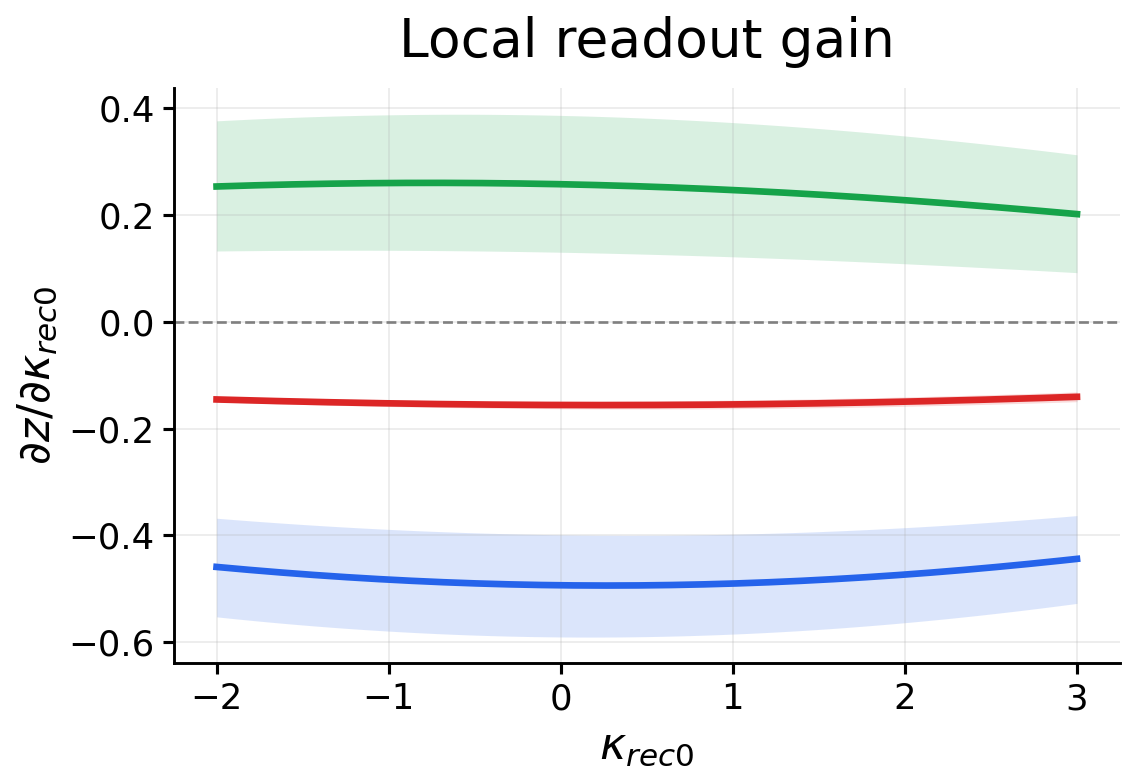

In [115]:
sims_stim1 = run_context_comparison_sims(
    models["low_rank"],
    stimulus=1,
    seq_len=10,
    context_mode="tonic",
)

gain_by_context = plot_dz_dkappa_rec_by_context(
    sims=sims_stim1,
    kappa_rec_range=(-2, 3),
    grid_n=160,
    fixed_t_values=range(2, 9),
    fixed_from="pre",
    absolute=False,
    show_ci=True,
    show_trajectory_points=False,
)


,trial,context,stimulus,target,final_output,prediction,correct
0,0,0,-1,0.0,1.579523e-06,0.0,True
1,1,0,1,0.0,3.278255e-07,0.0,True
2,2,1,-1,-1.0,-9.999995e-01,-1.0,True
3,3,1,1,1.0,1.000000e+00,1.0,True
4,4,2,-1,1.0,9.999993e-01,1.0,True
5,5,2,1,-1.0,-9.999993e-01,-1.0,True


Mean readout gain by context and stimulus:
   context  stimulus  mean_dz_dkappa_rec0
0        0        -1            -0.148610
1        0         1            -0.145321
2        1        -1             0.295496
3        1         1             0.294292
4        2        -1            -0.526076
5        2         1            -0.527862


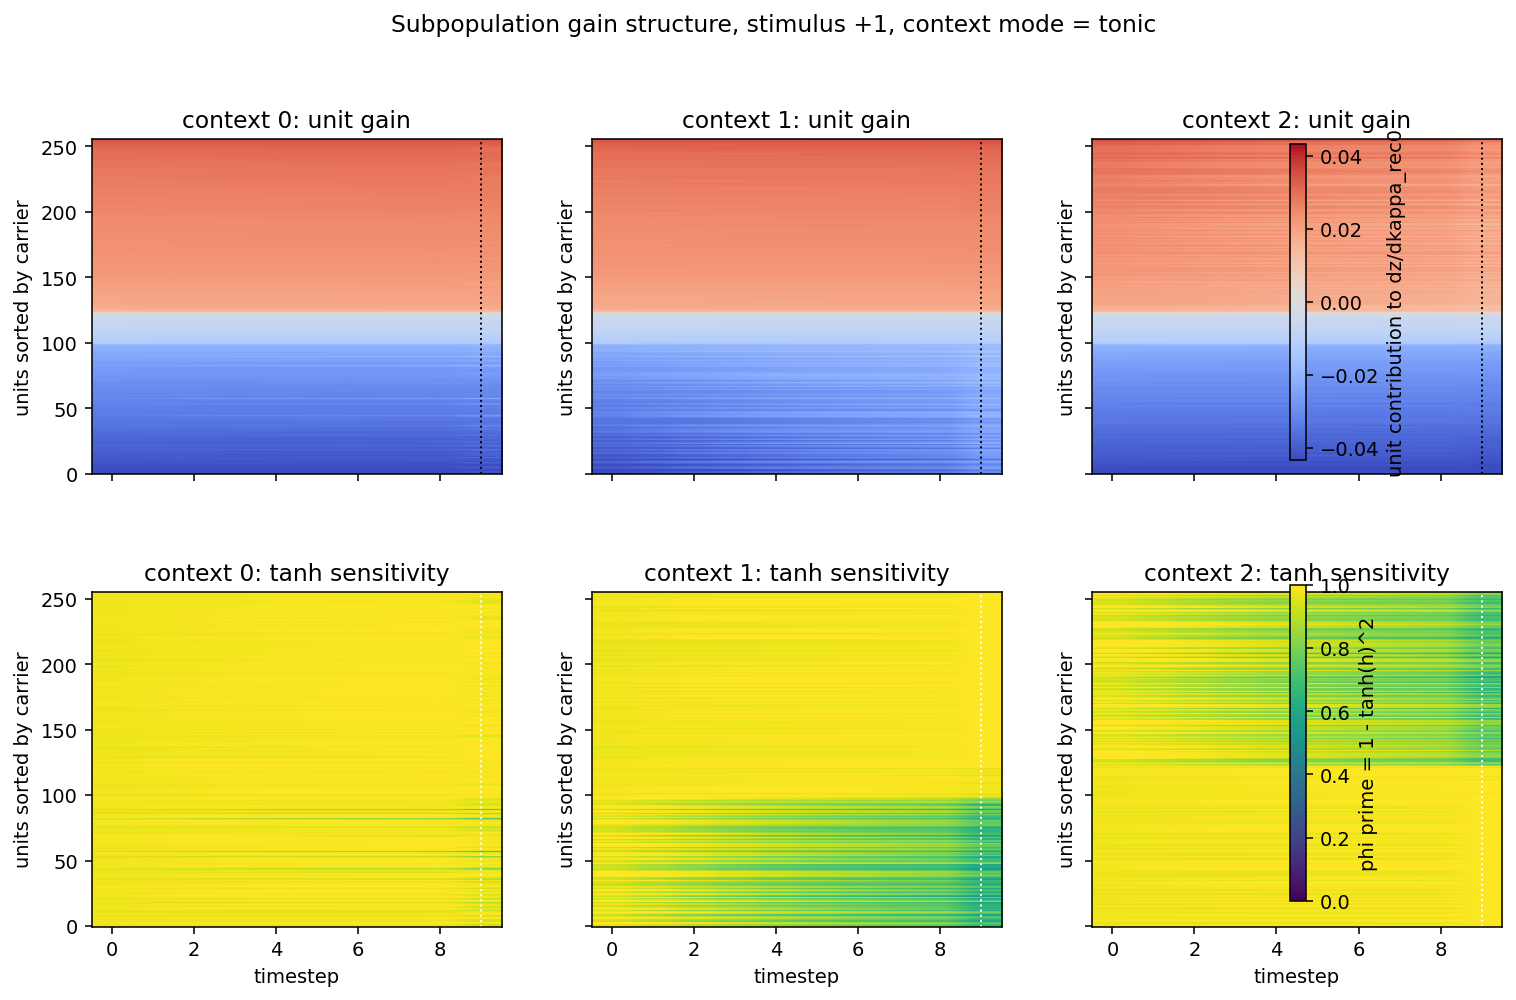

,context,stimulus,group,n_units,mean_phi_prime,mean_abs_rate,signed_gain_sum,abs_gain_sum,time_window
0,0,1,negative carrier,38,0.982239,0.115544,-1.502343,1.502343,2-8
1,0,1,positive carrier,38,0.988587,0.100431,1.139440,1.139440,2-8
2,0,1,largest |carrier|,38,0.982094,0.116076,-1.423965,1.509743,2-8
3,1,1,negative carrier,38,0.821905,0.405329,-1.258502,1.258502,2-8
4,1,1,positive carrier,38,0.988869,0.083003,1.140057,1.140057,2-8
5,1,1,largest |carrier|,38,0.827583,0.393891,-1.186367,1.274063,2-8
6,2,1,negative carrier,38,0.983386,0.104018,-1.503811,1.503811,2-8
7,2,1,positive carrier,38,0.861174,0.356766,0.993045,0.993045,2-8
8,2,1,largest |carrier|,38,0.978615,0.114339,-1.431875,1.503617,2-8


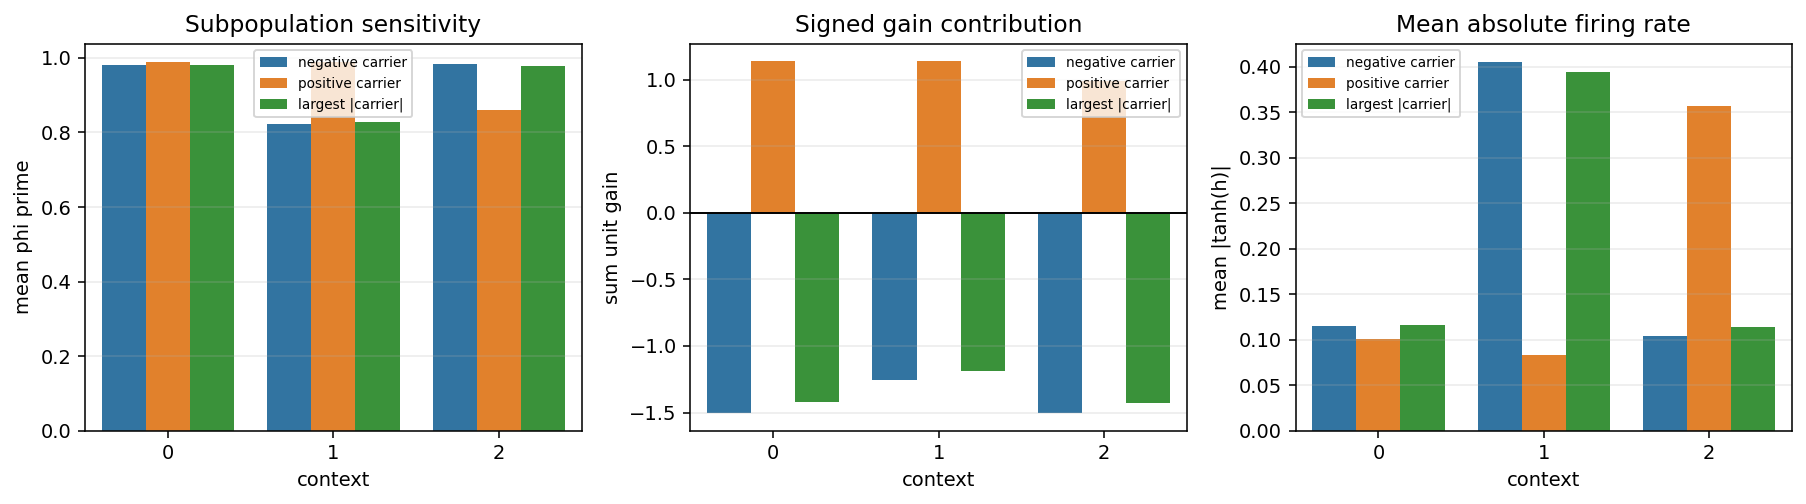

,ablation,context,stimulus,target,final_output,prediction,correct,n_ablated,random_repeat
0,none,0,-1,0.0,1.579523e-06,0.0,True,0,NaN
1,none,0,1,0.0,3.278255e-07,0.0,True,0,NaN
2,none,1,-1,-1.0,-9.999995e-01,-1.0,True,0,NaN
3,none,1,1,1.0,1.000000e+00,1.0,True,0,NaN
4,none,2,-1,1.0,9.999993e-01,1.0,True,0,NaN


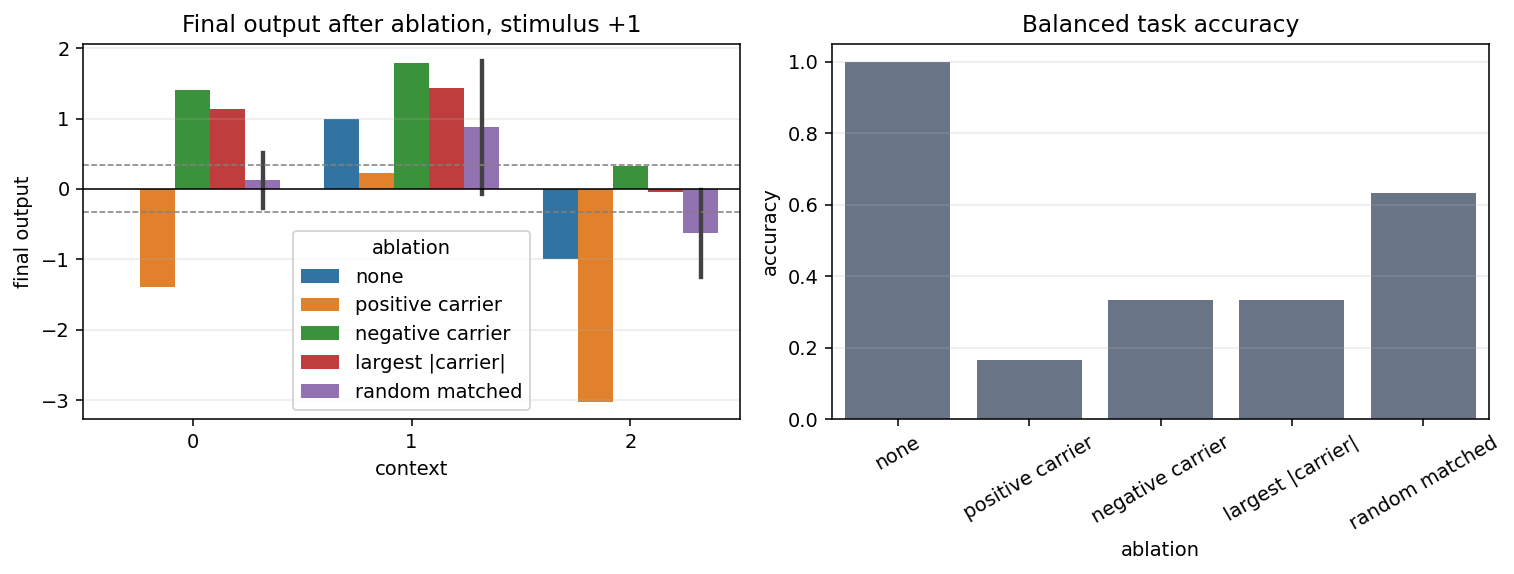

,ablation,accuracy
2,none,1.000000
4,random matched,0.633333
0,largest |carrier|,0.333333
1,negative carrier,0.333333
3,positive carrier,0.166667


In [98]:
# Context-gated subpopulation hypothesis test for the trained low-rank RNN.
# This cell is self-contained: it uses models["low_rank"] directly and builds
# tonic-context test trials without relying on ContextGoNoGoTask.

import numpy as np
import pandas as pd
import torch as T
import matplotlib.pyplot as plt
import seaborn as sns

CONTEXT_COLORS = {0: "#dc2626", 1: "#16a34a", 2: "#2563eb"}
INPUT_NAMES = ["stimulus", "cond_0", "cond_1", "cond_2", "go_cue"]


def make_gonogo_batch_for_analysis(
    repeats_per_case=1,
    seq_len=10,
    context_mode="tonic",
    device=None,
):
    """
    Build deterministic 3-context Go/No-Go test trials.

    context_mode="tonic": context one-hot is present at all timesteps.
    context_mode="brief": context at t=0, stimulus at t=1, go cue at final step.
    """
    if device is None:
        device = DEVICE

    cases = [(c, s) for c in range(3) for s in (-1.0, 1.0)]
    contexts = T.tensor(
        [c for c, _ in cases for _ in range(repeats_per_case)],
        dtype=T.long,
        device=device,
    )
    stimuli = T.tensor(
        [s for _, s in cases for _ in range(repeats_per_case)],
        dtype=T.float32,
        device=device,
    )

    inputs = T.zeros(contexts.numel(), seq_len, 5, device=device)

    if context_mode == "tonic":
        inputs[:, :, 1:4] = T.nn.functional.one_hot(contexts, 3).float().unsqueeze(1)
        inputs[:, 0, 0] = stimuli
    elif context_mode == "brief":
        inputs[:, 0, 1:4] = T.nn.functional.one_hot(contexts, 3).float()
        inputs[:, 1, 0] = stimuli
    else:
        raise ValueError("context_mode must be 'tonic' or 'brief'.")

    inputs[:, -1, 4] = 1.0

    targets = T.zeros_like(stimuli)
    targets = T.where(contexts == 1, stimuli, targets)
    targets = T.where(contexts == 2, -stimuli, targets)

    return inputs, targets.unsqueeze(1), contexts, stimuli


@T.no_grad()
def low_rank_forward_with_rate_ablation(model, inputs, ablated_units=None):
    """
    Run the low-rank RNN while silencing selected units' rates.

    The mask is applied to tanh(h) both before recurrent feedback and before
    readout. This is a stronger causal perturbation than readout-only masking.
    """
    batch_size, seq_len, _ = inputs.shape
    h = model.h0.expand(batch_size, -1)

    mask = T.ones(model.hidden_size, device=inputs.device)
    if ablated_units is not None and len(ablated_units) > 0:
        mask[T.as_tensor(ablated_units, dtype=T.long, device=inputs.device)] = 0.0

    outputs = []
    states = []

    for t in range(seq_len):
        rates = T.tanh(h) * mask
        recurrent = (rates @ model.V) @ model.U.t()
        recurrent = recurrent / model.hidden_size
        input_drive = inputs[:, t, :] @ model.W_in.t()
        h = h + model.alpha * (-h + recurrent + input_drive)

        rates = T.tanh(h) * mask
        y = rates @ model.W_out.t()
        outputs.append(y)
        states.append(h)

    return T.stack(outputs, dim=1), T.stack(states, dim=1)


def discretize_np(y, threshold=1.0 / 3.0):
    y = np.asarray(y)
    return np.where(y > threshold, 1.0, np.where(y < -threshold, -1.0, 0.0))


def compute_low_rank_subpopulation_diagnostics(
    model=None,
    repeats_per_case=1,
    seq_len=None,
    context_mode="tonic",
    rec_idx=0,
    device=None,
):
    """
    Compute per-unit contributions to dz/dkappa_rec0.

    Returns a dictionary with:
    - carrier_i = W_out_i * q_rec0_i
    - phi_prime = 1 - tanh(h)^2
    - unit_gain = carrier_i * phi_prime_i
    - readout_gain = sum_i unit_gain_i
    """
    if model is None:
        model = models["low_rank"]
    if device is None:
        device = DEVICE
    if seq_len is None:
        seq_len = int(getattr(model_args.get("low_rank", object()), "seq_len", 10))

    model = model.to(device)
    model.eval()

    inputs, targets, contexts, stimuli = make_gonogo_batch_for_analysis(
        repeats_per_case=repeats_per_case,
        seq_len=seq_len,
        context_mode=context_mode,
        device=device,
    )

    with T.no_grad():
        outputs, states = model(inputs, return_states=True)

    states_np = states.detach().cpu().numpy()
    outputs_np = outputs.detach().cpu().numpy().squeeze(-1)
    contexts_np = contexts.detach().cpu().numpy()
    stimuli_np = stimuli.detach().cpu().numpy().astype(int)
    targets_np = targets.detach().cpu().numpy().squeeze(-1)

    U = model.U.detach().cpu().numpy()
    W_out = model.W_out.detach().cpu().numpy()[0]

    q_rec0 = U[:, rec_idx].copy()
    q_rec0 = q_rec0 / (np.linalg.norm(q_rec0) + 1e-12)

    carrier = W_out * q_rec0
    rates = np.tanh(states_np)
    phi_prime = 1.0 - rates ** 2
    unit_gain = phi_prime * carrier[None, None, :]
    readout_gain = unit_gain.sum(axis=-1)

    pred = discretize_np(outputs_np[:, -1])

    trial_table = pd.DataFrame({
        "trial": np.arange(len(contexts_np)),
        "context": contexts_np,
        "stimulus": stimuli_np,
        "target": targets_np,
        "final_output": outputs_np[:, -1],
        "prediction": pred,
        "correct": pred == targets_np,
    })

    return {
        "model": model,
        "inputs": inputs,
        "targets": targets,
        "contexts": contexts_np,
        "stimuli": stimuli_np,
        "states": states_np,
        "outputs": outputs_np,
        "rates": rates,
        "phi_prime": phi_prime,
        "unit_gain": unit_gain,
        "readout_gain": readout_gain,
        "carrier": carrier,
        "q_rec0": q_rec0,
        "W_out": W_out,
        "trial_table": trial_table,
        "context_mode": context_mode,
        "seq_len": seq_len,
        "rec_idx": rec_idx,
    }


def select_carrier_subpopulations(carrier, top_frac=0.15, min_units=5):
    """Select positive, negative, and high-absolute carrier subpopulations."""
    carrier = np.asarray(carrier)
    n_units = carrier.size
    n_select = max(min_units, int(round(top_frac * n_units)))
    n_select = min(n_select, n_units)

    order = np.argsort(carrier)
    abs_order = np.argsort(np.abs(carrier))

    return {
        "negative carrier": order[:n_select],
        "positive carrier": order[-n_select:],
        "largest |carrier|": abs_order[-n_select:],
    }


def plot_unit_gain_and_saturation_heatmaps(
    diag,
    stimulus=1,
    sort_by="carrier",
    max_units=None,
    figsize=(13, 7.5),
):
    """
    Heatmaps showing which units transmit the recurrent latent to output.

    Top row: signed unit gain W_out_i * q_rec_i * phi_prime_i.
    Bottom row: phi_prime_i, showing whether units are saturated or sensitive.
    """
    carrier = diag["carrier"]

    if sort_by == "carrier":
        unit_order = np.argsort(carrier)
    elif sort_by == "abs_carrier":
        unit_order = np.argsort(np.abs(carrier))
    else:
        raise ValueError("sort_by must be 'carrier' or 'abs_carrier'.")

    if max_units is not None and max_units < len(unit_order):
        if sort_by == "carrier":
            half = max_units // 2
            unit_order = np.r_[unit_order[:half], unit_order[-(max_units - half):]]
        else:
            unit_order = unit_order[-max_units:]

    mask_stim = diag["stimuli"] == stimulus

    gain_lim = np.percentile(np.abs(diag["unit_gain"][:, :, unit_order]), 99)
    gain_lim = max(gain_lim, 1e-8)

    fig, axes = plt.subplots(2, 3, figsize=figsize, dpi=140, sharex=True, sharey="row")

    for col, context_id in enumerate([0, 1, 2]):
        trial_mask = mask_stim & (diag["contexts"] == context_id)

        mean_gain = diag["unit_gain"][trial_mask].mean(axis=0)[:, unit_order].T
        mean_phi_prime = diag["phi_prime"][trial_mask].mean(axis=0)[:, unit_order].T

        ax = axes[0, col]
        im0 = ax.imshow(
            mean_gain,
            aspect="auto",
            origin="lower",
            cmap="coolwarm",
            vmin=-gain_lim,
            vmax=gain_lim,
        )
        ax.set_title(f"context {context_id}: unit gain")
        ax.set_ylabel("units sorted by carrier")
        ax.axvline(diag["seq_len"] - 1, color="black", ls=":", lw=1)

        ax = axes[1, col]
        im1 = ax.imshow(
            mean_phi_prime,
            aspect="auto",
            origin="lower",
            cmap="viridis",
            vmin=0,
            vmax=1,
        )
        ax.set_title(f"context {context_id}: tanh sensitivity")
        ax.set_xlabel("timestep")
        ax.set_ylabel("units sorted by carrier")
        ax.axvline(diag["seq_len"] - 1, color="white", ls=":", lw=1)

    fig.colorbar(im0, ax=axes[0, :], shrink=0.86, label="unit contribution to dz/dkappa_rec0")
    fig.colorbar(im1, ax=axes[1, :], shrink=0.86, label="phi prime = 1 - tanh(h)^2")

    fig.suptitle(
        f"Subpopulation gain structure, stimulus {stimulus:+d}, context mode = {diag['context_mode']}",
        y=0.98,
    )
    fig.subplots_adjust(top=0.86, hspace=0.35, wspace=0.22)
    plt.show()


def summarize_subpopulation_gating(
    diag,
    top_frac=0.15,
    stimulus=1,
    time_window=None,
):
    """Summarize sensitivity and gain contribution for carrier subpopulations."""
    if time_window is None:
        # Delay/context window: skip the stimulus transient and the final go cue.
        time_window = np.arange(2, diag["seq_len"] - 1)

    subpops = select_carrier_subpopulations(diag["carrier"], top_frac=top_frac)
    rows = []

    for context_id in [0, 1, 2]:
        trial_mask = (diag["contexts"] == context_id) & (diag["stimuli"] == stimulus)

        for group_name, unit_idx in subpops.items():
            phi_block = diag["phi_prime"][trial_mask][:, time_window][:, :, unit_idx]
            gain_block = diag["unit_gain"][trial_mask][:, time_window][:, :, unit_idx]
            rate_block = diag["rates"][trial_mask][:, time_window][:, :, unit_idx]

            rows.append({
                "context": context_id,
                "stimulus": stimulus,
                "group": group_name,
                "n_units": len(unit_idx),
                "mean_phi_prime": float(phi_block.mean()),
                "mean_abs_rate": float(np.abs(rate_block).mean()),
                "signed_gain_sum": float(gain_block.sum(axis=-1).mean()),
                "abs_gain_sum": float(np.abs(gain_block).sum(axis=-1).mean()),
                "time_window": f"{int(time_window[0])}-{int(time_window[-1])}",
            })

    return pd.DataFrame(rows)


def plot_subpopulation_gating_summary(summary_df, figsize=(13, 3.7)):
    fig, axes = plt.subplots(1, 3, figsize=figsize, dpi=140)

    sns.barplot(
        data=summary_df,
        x="context",
        y="mean_phi_prime",
        hue="group",
        ax=axes[0],
    )
    axes[0].set_title("Subpopulation sensitivity")
    axes[0].set_ylabel("mean phi prime")

    sns.barplot(
        data=summary_df,
        x="context",
        y="signed_gain_sum",
        hue="group",
        ax=axes[1],
    )
    axes[1].axhline(0, color="black", lw=1)
    axes[1].set_title("Signed gain contribution")
    axes[1].set_ylabel("sum unit gain")

    sns.barplot(
        data=summary_df,
        x="context",
        y="mean_abs_rate",
        hue="group",
        ax=axes[2],
    )
    axes[2].set_title("Mean absolute firing rate")
    axes[2].set_ylabel("mean |tanh(h)|")

    for ax in axes:
        ax.grid(True, axis="y", alpha=0.25)
        ax.legend(fontsize=7)

    plt.tight_layout()
    plt.show()


def run_low_rank_subpopulation_ablation_tests(
    diag,
    top_frac=0.15,
    include_random=True,
    random_repeats=20,
    seed=123,
):
    """Ablate selected subpopulations and evaluate final task output."""
    model = diag["model"]
    inputs = diag["inputs"]
    contexts = diag["contexts"]
    stimuli = diag["stimuli"]
    targets = diag["targets"].detach().cpu().numpy().squeeze(-1)

    subpops = select_carrier_subpopulations(diag["carrier"], top_frac=top_frac)
    ablation_sets = {"none": np.array([], dtype=int), **subpops}

    rng = np.random.default_rng(seed)
    n_units = diag["carrier"].size
    n_select = len(next(iter(subpops.values())))

    rows = []

    for label, unit_idx in ablation_sets.items():
        outputs, _ = low_rank_forward_with_rate_ablation(model, inputs, unit_idx)
        final_output = outputs[:, -1, 0].detach().cpu().numpy()
        pred = discretize_np(final_output)

        for i in range(len(contexts)):
            rows.append({
                "ablation": label,
                "context": int(contexts[i]),
                "stimulus": int(stimuli[i]),
                "target": float(targets[i]),
                "final_output": float(final_output[i]),
                "prediction": float(pred[i]),
                "correct": bool(pred[i] == targets[i]),
                "n_ablated": int(len(unit_idx)),
            })

    if include_random:
        for r in range(random_repeats):
            unit_idx = rng.choice(n_units, size=n_select, replace=False)
            outputs, _ = low_rank_forward_with_rate_ablation(model, inputs, unit_idx)
            final_output = outputs[:, -1, 0].detach().cpu().numpy()
            pred = discretize_np(final_output)

            for i in range(len(contexts)):
                rows.append({
                    "ablation": "random matched",
                    "random_repeat": r,
                    "context": int(contexts[i]),
                    "stimulus": int(stimuli[i]),
                    "target": float(targets[i]),
                    "final_output": float(final_output[i]),
                    "prediction": float(pred[i]),
                    "correct": bool(pred[i] == targets[i]),
                    "n_ablated": int(n_select),
                })

    return pd.DataFrame(rows)


def plot_ablation_effects(ablation_df, stimulus=1, figsize=(11, 4.2)):
    """Plot how subpopulation ablations change final output and accuracy."""
    plot_df = ablation_df[ablation_df["stimulus"] == stimulus].copy()

    order = [
        "none",
        "positive carrier",
        "negative carrier",
        "largest |carrier|",
        "random matched",
    ]
    order = [x for x in order if x in plot_df["ablation"].unique()]

    fig, axes = plt.subplots(1, 2, figsize=figsize, dpi=140)

    sns.barplot(
        data=plot_df,
        x="context",
        y="final_output",
        hue="ablation",
        hue_order=order,
        errorbar="sd",
        ax=axes[0],
    )
    axes[0].axhline(1 / 3, color="grey", ls="--", lw=0.8)
    axes[0].axhline(-1 / 3, color="grey", ls="--", lw=0.8)
    axes[0].axhline(0, color="black", lw=0.8)
    axes[0].set_title(f"Final output after ablation, stimulus {stimulus:+d}")
    axes[0].set_ylabel("final output")
    axes[0].grid(True, axis="y", alpha=0.25)

    acc_df = (
        ablation_df
        .groupby("ablation", as_index=False)["correct"]
        .mean()
        .rename(columns={"correct": "accuracy"})
    )

    sns.barplot(
        data=acc_df,
        x="ablation",
        y="accuracy",
        order=order,
        color="#64748b",
        ax=axes[1],
    )
    axes[1].set_ylim(0, 1.05)
    axes[1].set_title("Balanced task accuracy")
    axes[1].set_xlabel("ablation")
    axes[1].set_ylabel("accuracy")
    axes[1].tick_params(axis="x", rotation=30)
    axes[1].grid(True, axis="y", alpha=0.25)

    plt.tight_layout()
    plt.show()

    display(acc_df.sort_values("accuracy", ascending=False))


# ---- Run the hypothesis test ----
# Use context_mode="tonic" for the network trained with context present across the trial.
# Switch to context_mode="brief" only when analyzing the short-context-trained model.
subpop_diag = compute_low_rank_subpopulation_diagnostics(
    model=models["low_rank"],
    repeats_per_case=1,
    seq_len=int(model_args["low_rank"].seq_len),
    context_mode="tonic",
    rec_idx=0,
    device=DEVICE,
)

display(subpop_diag["trial_table"])
print("Mean readout gain by context and stimulus:")
print(
    pd.DataFrame({
        "context": subpop_diag["contexts"],
        "stimulus": subpop_diag["stimuli"],
        "mean_dz_dkappa_rec0": subpop_diag["readout_gain"].mean(axis=1),
    })
)

plot_unit_gain_and_saturation_heatmaps(
    subpop_diag,
    stimulus=1,
    sort_by="carrier",
    max_units=None,
)

subpop_summary = summarize_subpopulation_gating(
    subpop_diag,
    top_frac=0.15,
    stimulus=1,
)
display(subpop_summary)
plot_subpopulation_gating_summary(subpop_summary)

ablation_df = run_low_rank_subpopulation_ablation_tests(
    subpop_diag,
    top_frac=0.15,
    include_random=True,
    random_repeats=20,
)
display(ablation_df.head())
plot_ablation_effects(ablation_df, stimulus=1)


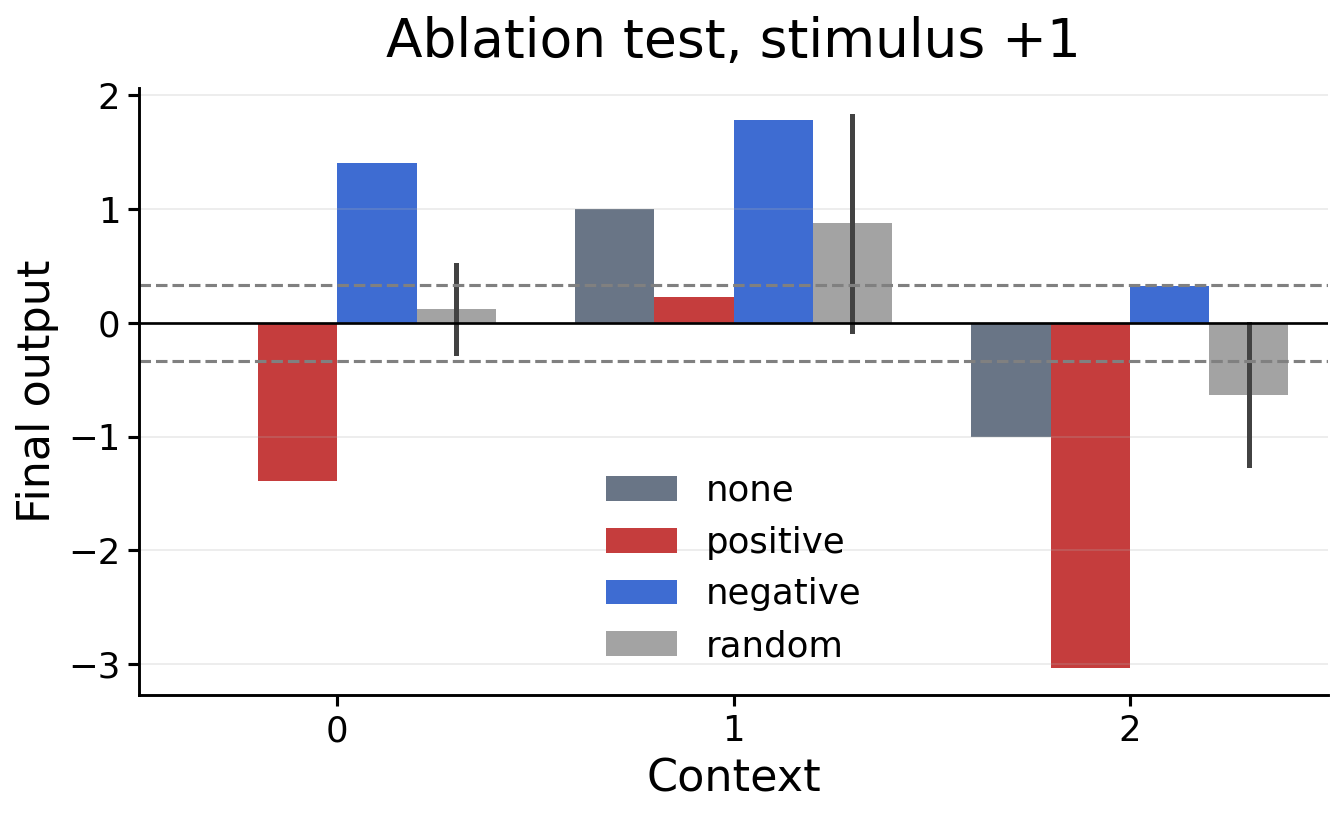

In [129]:
def plot_ablation_effects(
    ablation_df,
    stimulus=1,
    figsize=(8.5, 5.2),
    title_fontsize=24,
    label_fontsize=20,
    tick_fontsize=16,
):
    """
    Slide-ready ablation plot.

    Shows final output for each context under:
    none, positive carrier ablation, negative carrier ablation, random ablation.
    """

    plot_df = ablation_df[ablation_df["stimulus"] == stimulus].copy()

    # Rename only for plotting.
    plot_df["ablation_plot"] = plot_df["ablation"].replace({
        "random matched": "random",
        "positive carrier": "positive",
        "negative carrier": "negative",
    })

    order = ["none", "positive", "negative", "random"]
    plot_df = plot_df[plot_df["ablation_plot"].isin(order)].copy()

    fig, ax = plt.subplots(1, 1, figsize=figsize, dpi=160)

    sns.barplot(
        data=plot_df,
        x="context",
        y="final_output",
        hue="ablation_plot",
        hue_order=order,
        errorbar="sd",
        palette={
            "none": "#64748b",
            "positive": "#dc2626",
            "negative": "#2563eb",
            "random": "#a3a3a3",
        },
        ax=ax,
    )

    ax.axhline(1 / 3, color="grey", ls="--", lw=1.4)
    ax.axhline(-1 / 3, color="grey", ls="--", lw=1.4)
    ax.axhline(0, color="black", lw=1.2)

    ax.set_title(f"Ablation test, stimulus {stimulus:+d}", fontsize=title_fontsize, pad=14)
    ax.set_xlabel("Context", fontsize=label_fontsize)
    ax.set_ylabel("Final output", fontsize=label_fontsize)

    ax.tick_params(axis="both", labelsize=tick_fontsize, width=1.4, length=5)

    ax.legend(
        title=None,
        fontsize=tick_fontsize,
        frameon=False,
        loc="best",
    )

    ax.grid(True, axis="y", alpha=0.25)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_linewidth(1.3)
    ax.spines["bottom"].set_linewidth(1.3)

    plt.tight_layout()
    plt.show()
plot_ablation_effects(ablation_df, stimulus=1)

In [112]:
def plot_unit_gain_and_firing_rate_heatmaps(
    diag,
    stimulus=1,
    sort_by="m",
    max_units=None,
    figsize=(18, 8.2),
    title_fontsize=24,
    label_fontsize=20,
    tick_fontsize=16,
    cbar_fontsize=17,
):
    """
    Slide-ready heatmaps for context-dependent subpopulation structure.

    Rows:
    1. Unit gain: W_out_i * q_rec_i * phi_prime_i
    2. Firing rate: tanh(h_i)

    Units are sorted from negative to positive m_i by default.
    """
    carrier = diag["carrier"]
    m_rec0 = diag["m_rec0"] if "m_rec0" in diag else diag["q_rec0"]

    if sort_by == "m":
        unit_order = np.argsort(m_rec0)
    elif sort_by == "carrier":
        unit_order = np.argsort(carrier)
    elif sort_by == "abs_carrier":
        unit_order = np.argsort(np.abs(carrier))
    else:
        raise ValueError("sort_by must be 'm', 'carrier', or 'abs_carrier'.")

    if max_units is not None and max_units < len(unit_order):
        if sort_by in ["m", "carrier"]:
            half = max_units // 2
            unit_order = np.r_[unit_order[:half], unit_order[-(max_units - half):]]
        else:
            unit_order = unit_order[-max_units:]

    mask_stim = diag["stimuli"] == stimulus

    gain_lim = np.percentile(np.abs(diag["unit_gain"][:, :, unit_order]), 99)
    gain_lim = max(gain_lim, 1e-8)

    fig, axes = plt.subplots(
        2,
        3,
        figsize=figsize,
        dpi=160,
        sharex=True,
        sharey="row",
        constrained_layout=True,
    )

    for col, context_id in enumerate([0, 1, 2]):
        trial_mask = mask_stim & (diag["contexts"] == context_id)

        mean_gain = diag["unit_gain"][trial_mask].mean(axis=0)[:, unit_order].T
        mean_rate = diag["rates"][trial_mask].mean(axis=0)[:, unit_order].T

        ax = axes[0, col]
        im0 = ax.imshow(
            mean_gain,
            aspect="auto",
            origin="lower",
            cmap="coolwarm",
            vmin=-gain_lim,
            vmax=gain_lim,
            interpolation="nearest",
        )
        ax.axvline(diag["seq_len"] - 1, color="black", ls=":", lw=2.0)

        ax = axes[1, col]
        im1 = ax.imshow(
            mean_rate,
            aspect="auto",
            origin="lower",
            cmap="coolwarm",
            vmin=-1,
            vmax=1,
            interpolation="nearest",
        )
        ax.axvline(diag["seq_len"] - 1, color="black", ls=":", lw=2.0)
        ax.set_xlabel("Time step", fontsize=label_fontsize)

    # Big row labels act as slide-readable subtitles.
    axes[0, 0].set_ylabel(
        r"Units sorted by contribution",
        fontsize=label_fontsize,
        labelpad=20,
    )
    axes[1, 0].set_ylabel(
        r"",
        fontsize=label_fontsize,
        labelpad=20,
    )

    for ax in axes.flat:
        ax.tick_params(axis="both", labelsize=tick_fontsize, width=1.4, length=5)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.spines["left"].set_linewidth(1.2)
        ax.spines["bottom"].set_linewidth(1.2)

    xticks = [0, diag["seq_len"] // 2, diag["seq_len"] - 1]
    for ax in axes[1, :]:
        ax.set_xticks(xticks)
        ax.set_xticklabels([str(x) for x in xticks])

    n_units_plotted = len(unit_order)
    yticks = [0, n_units_plotted // 2, n_units_plotted - 1]
    for row in range(2):
        axes[row, 0].set_yticks(yticks)
        axes[row, 0].set_yticklabels([str(y) for y in yticks])

    cbar0 = fig.colorbar(
        im0,
        ax=axes[0, :],
        shrink=0.92,
        pad=0.018,
        aspect=24,
    )
    cbar0.set_label(r"contribution to $\partial z / \partial \kappa_{rec0}$", fontsize=cbar_fontsize)
    cbar0.ax.tick_params(labelsize=tick_fontsize)

    cbar1 = fig.colorbar(
        im1,
        ax=axes[1, :],
        shrink=0.92,
        pad=0.018,
        aspect=24,
    )
    cbar1.set_label(r"$\tanh(h)$", fontsize=cbar_fontsize)
    cbar1.ax.tick_params(labelsize=tick_fontsize)

    axes[0, 2].text(
        diag["seq_len"] - 1,
        n_units_plotted + 4,
        "go cue",
        ha="center",
        va="bottom",
        fontsize=tick_fontsize,
        color="black",
    )

    fig.suptitle(
        f"Stimulus={stimulus:+d}",
        fontsize=title_fontsize,
        y=1.04,
    )

    plt.show()


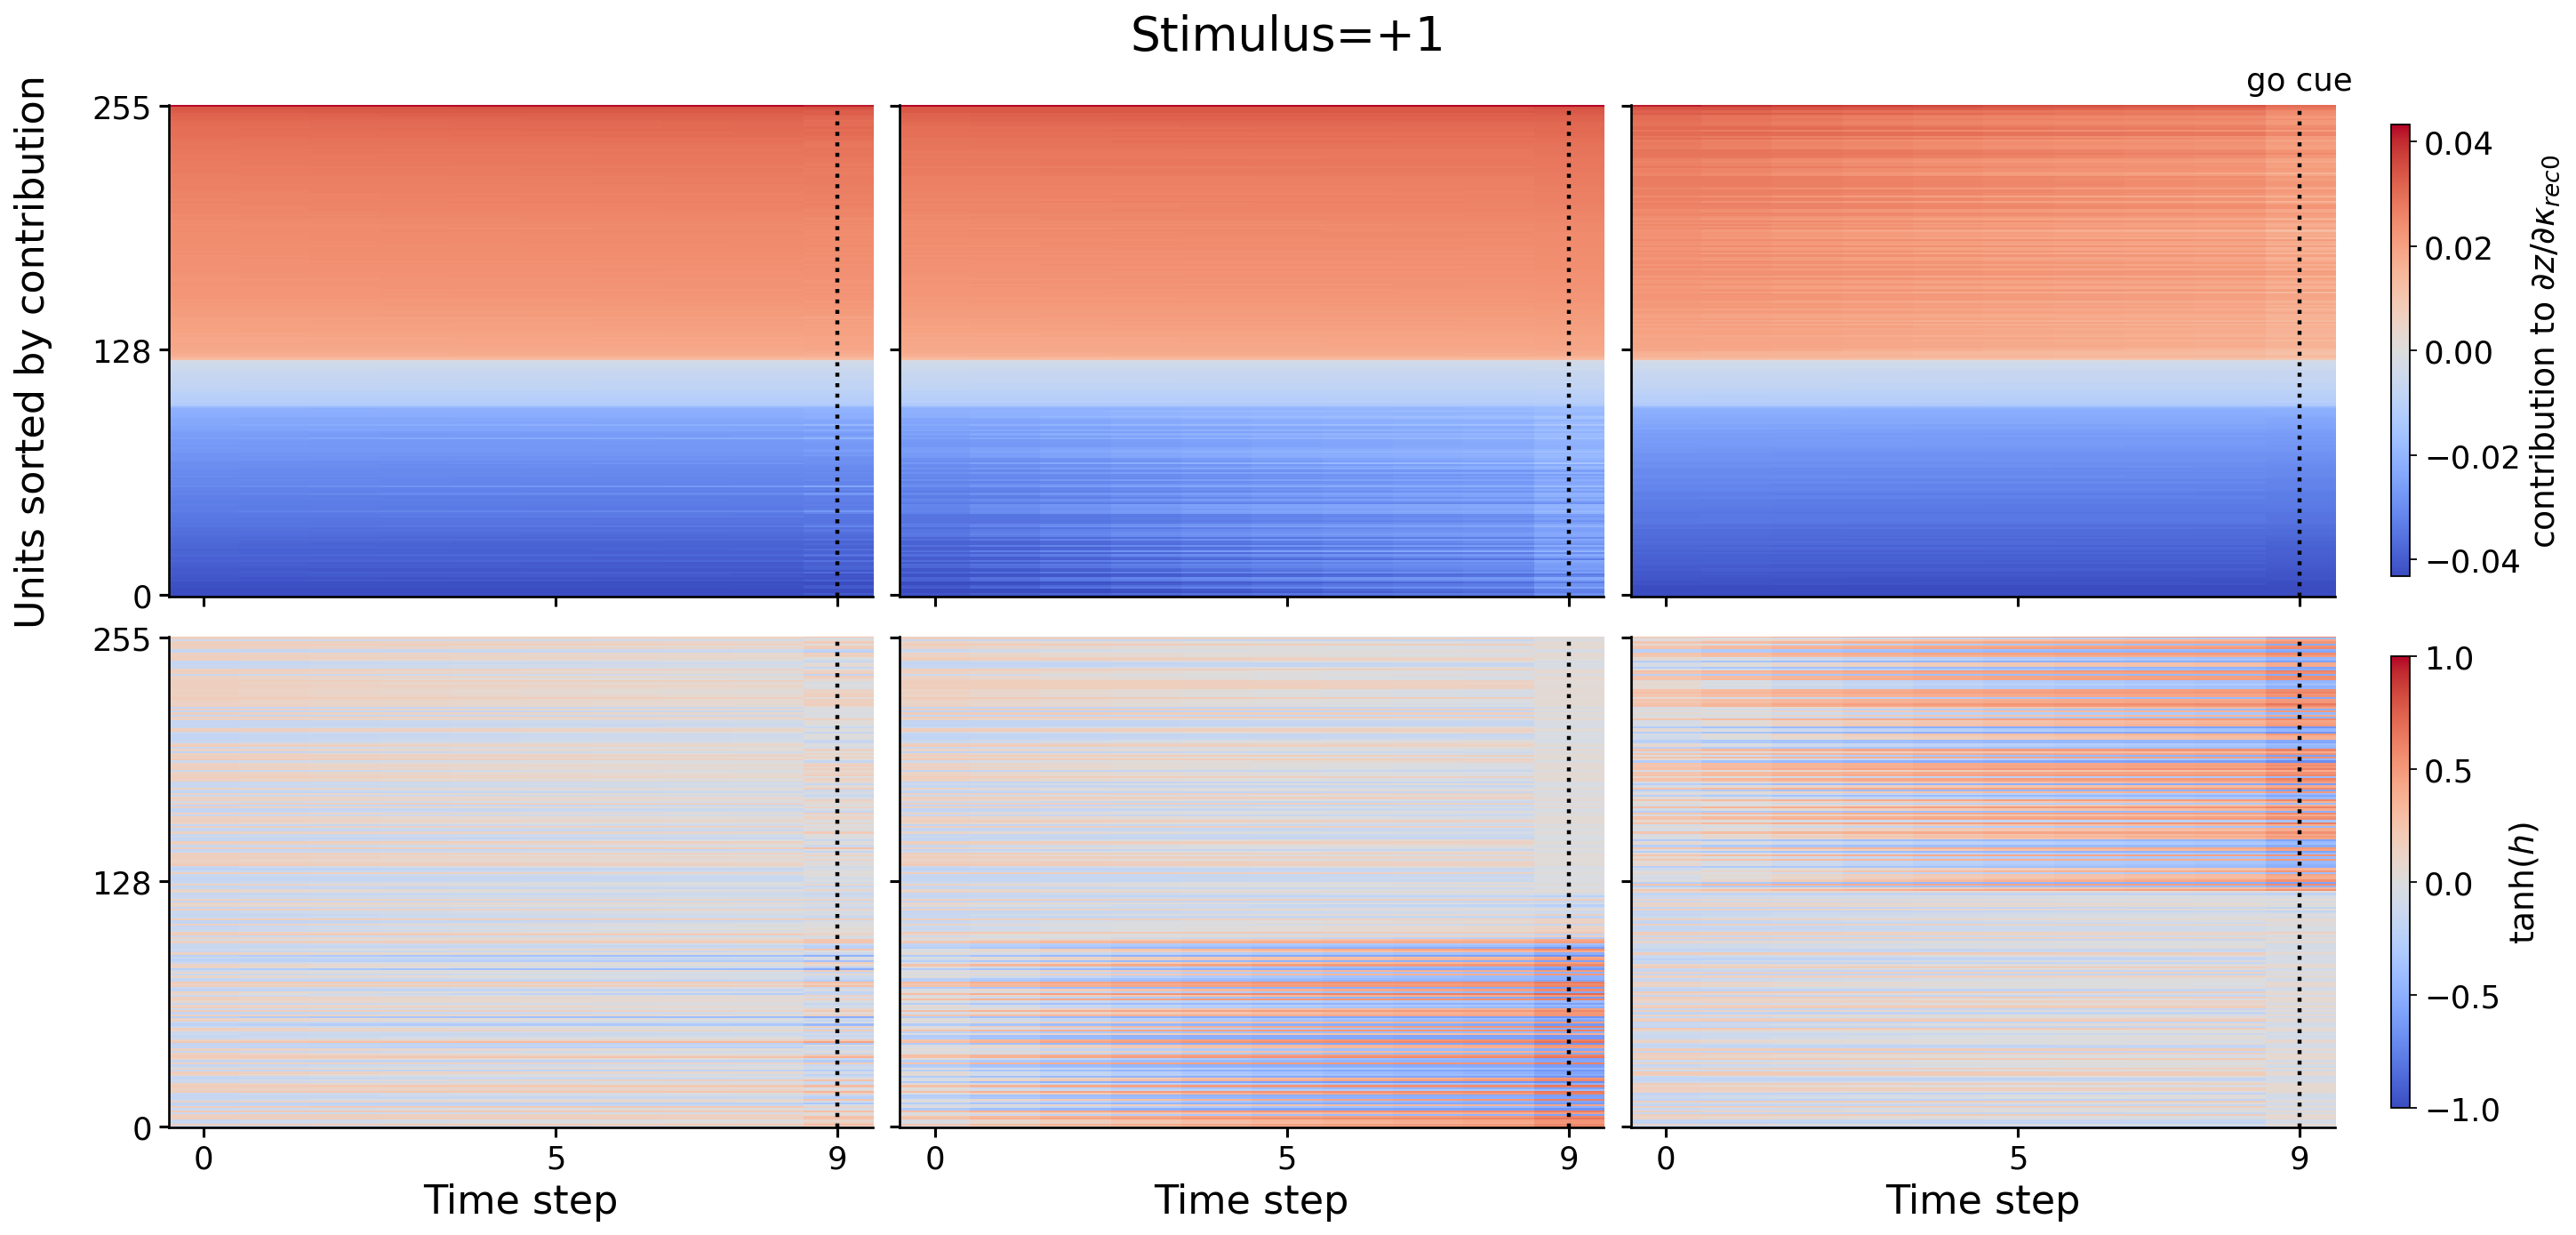

In [113]:
plot_unit_gain_and_firing_rate_heatmaps(
    subpop_diag,
    stimulus=1,
    sort_by="carrier",
    max_units=None,
)